In [4]:
import sklearn
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd
import os
import datetime as dt
import re 
import sys 
import importlib
from sklearn import preprocessing
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
	OneHotEncoder,
	OrdinalEncoder,
	RobustScaler,
)
from sklearn.preprocessing import (
	PowerTransformer, 
	QuantileTransformer
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler, QuantileTransformer, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import cross_validate
sklearn.set_config(enable_metadata_routing=False)
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector
from xgboost import XGBClassifier, XGBRegressor
import time 
import pandas as pd
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import pearsonr
import plotly.express as px
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import shap
shap.initjs()
import seaborn as sns

# Get the absolute path of the project root
project_root = os.path.abspath(os.path.join(os.getcwd(),".."))

# Add project root to sys.path for script usage
sys.path.append(project_root)

# Import and reload (optional) custom scripts
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables 
from scripts import feature_selection as fs
from scripts import paths
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)
importlib.reload(paths)


################ DEFINE column variables from data ###################
from scripts.variables import id_columns
from scripts.variables import all_cols, all_daily_cols, weekly_cols, baseline_cols, drop_weekly_cols
from scripts.variables import daily_cols_v1, daily_v2_sensor, daily_v2_sensor_hr, daily_v2_weather, daily_cols_v2 
from scripts.variables import gad_cols, phq9_base, alc_cols, phq9_cols, phq2_cols, sleep_cols, gic_cols, sds_cols


# Define label variables
df_names = ['v1_day', 'v2_day', 'v1_week', 'v2_week']
aggregate_dfs = ['alldays_df','week_df']
# Update endings list if order changes


# Filepaths
brighten_dir = paths.DATA
sub_dir = paths.SUB_DFS
results_dir = paths.RESULTS
outputs_dir = paths.OUTPUTS

########################################## MODELS #######################################


# Models
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
# Dummy baseline model
class GroupMeanRegressor(BaseEstimator, RegressorMixin):
	def fit(self, X, y, groups):
		self.group_means_ = y.groupby(groups.squeeze()).mean().squeeze()
		self.global_mean_ = y.mean().squeeze()
		return self
	
	def predict(self, X, groups):
		return groups.squeeze().map(self.group_means_).fillna(self.global_mean_).values

# Pearson scorer
def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

models = {
	# 'RandomForestRegressor': RandomForestRegressor(random_state=42),
	# 'XGBRegressor': XGBRegressor(objective='reg:squarederror', random_state=42),
	'HistGradientBoostingRegressor': HistGradientBoostingRegressor(),
	'GroupMeanRegressor': GroupMeanRegressor(),
	# 'Ridge': Ridge(alpha=1.0)
}
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr

def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

scoring_metrics = {
	'r2': 'r2',
	'neg_mae': 'neg_mean_absolute_error',
	'neg_rmse': 'neg_root_mean_squared_error',
}



# Histograms of all columns, and their transformed-possibilities, saved to 'charts'
### one at a time

In [ ]:

# Histograms of all columns, and their transformed-possibilities, saved to 'charts'
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Transformers
bc = preprocessing.PowerTransformer(method='box-cox', standardize=False)
yj = preprocessing.PowerTransformer(method='yeo-johnson', standardize=False)
qt = preprocessing.QuantileTransformer(output_distribution='normal', random_state=0)
scaler = preprocessing.StandardScaler()
robust = preprocessing.RobustScaler()

# Load numeric columns
for name in ['v1_day']:
    print(f'################# {name} ##################')
    train = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))
    
    num_cols_raw = selector(dtype_include="number")(train)
    num_cols_clean = [
        col for col in num_cols_raw 
        if 'indicator' not in col and col not in id_columns and 'Unnamed' not in col
    ]

    # 2.  ONLY the daily columns 
    target_cols = [
        col for col in num_cols_clean 
        if col in daily_cols_v1 + daily_v2_sensor
    ] # not including v2 weather cols 

    # Plot settings
    n_rows = len(target_cols)
    print(f'For {name}, {n_rows} features found. List: {target_cols}')
    if n_rows == 0:
        print(f"No matching columns found for {name}. Skipping...")
        continue

    n_cols = 7 # fit all transformations
    fig = plt.figure(figsize=(n_cols * 4, n_rows * 3))

    for i, col in enumerate(target_cols):
        # train[[col]] creates a 2D DataFrame, which sklearn transformers require
        col_data = train[[col]].dropna()  
        
        if col_data.empty:
            continue
            
        # 1. Raw Data
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 1)
        try:
            # Pass 1D series to seaborn
            sns.histplot(col_data[col], kde=True, ax=ax)
            ax.set_title(f"{col} - Raw")
        except Exception:
            ax.set_title(f"{col} (skipped)")
            continue # If raw data fails entirely, skip transforming it

        # 2. Box-Cox
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 2)
        try:
            transformed = bc.fit_transform(col_data)
            sns.histplot(transformed.flatten(), kde=True, ax=ax)
            ax.set_title("Box-Cox")
        except Exception:
            ax.set_title("Box-Cox (skipped)")

        # 3. Yeo-Johnson
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 3)
        try:
            transformed = yj.fit_transform(col_data)
            sns.histplot(transformed.flatten(), kde=True, ax=ax)
            ax.set_title("Yeo-Johnson")
        except Exception:
            ax.set_title("Yeo-Johnson (skipped)")

        # 4. QuantileTransformer
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 4)
        try:
            transformed = qt.fit_transform(col_data)
            sns.histplot(transformed.flatten(), kde=True, ax=ax)
            ax.set_title("Quantile")
        except Exception:
            ax.set_title("Quantile (skipped)")

        # 5. StandardScaler
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 5)
        try:
            transformed = scaler.fit_transform(col_data)
            sns.histplot(transformed.flatten(), kde=True, ax=ax)
            ax.set_title("StandardScaler")
        except Exception:
            ax.set_title("StandardScaler (skipped)")

        # 6. RobustScaler
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 6)
        try:
            transformed = robust.fit_transform(col_data)
            sns.histplot(transformed.flatten(), kde=True, ax=ax)
            ax.set_title("RobustScaler")
        except Exception:
            ax.set_title("RobustScaler (skipped)")

        # 7. Log Transform
        ax = plt.subplot(n_rows, n_cols, i * n_cols + 7)
        try:
            transformed = np.log(col_data[col])
            sns.histplot(transformed, kde=True, ax=ax)
            ax.set_title("Log")
        except Exception:
            ax.set_title("Log (skipped)")

    plt.tight_layout()
    
    charts_dir = os.path.join(project_root, 'charts')
    os.makedirs(charts_dir, exist_ok=True)
    
    save_path = os.path.join(charts_dir, f'{name}_histograms_transformation-options.png')
    fig.savefig(save_path, dpi=80)
    plt.close(fig)

Run on: Mon 13 Apr 2026, 09:44AM
################# v2_day ##################
For v2_day, 10 features found. List: ['distance_active', 'distance_walking', 'hours_high_speed_transportation', 'came_to_work', 'distance_powered_vehicle', 'location_variance', 'distance_high_speed_transportation', 'hours_powered_vehicle', 'hours_active', 'hours_of_sleep']


/Users/klj9278/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/klj9278/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/klj9278/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/klj9278/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/klj9278/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/klj9278/miniconda3/lib/python3.13/site-packages/pandas/cor

Run on: Fri 10 Apr 2026, 08:43AM
v1_day
108


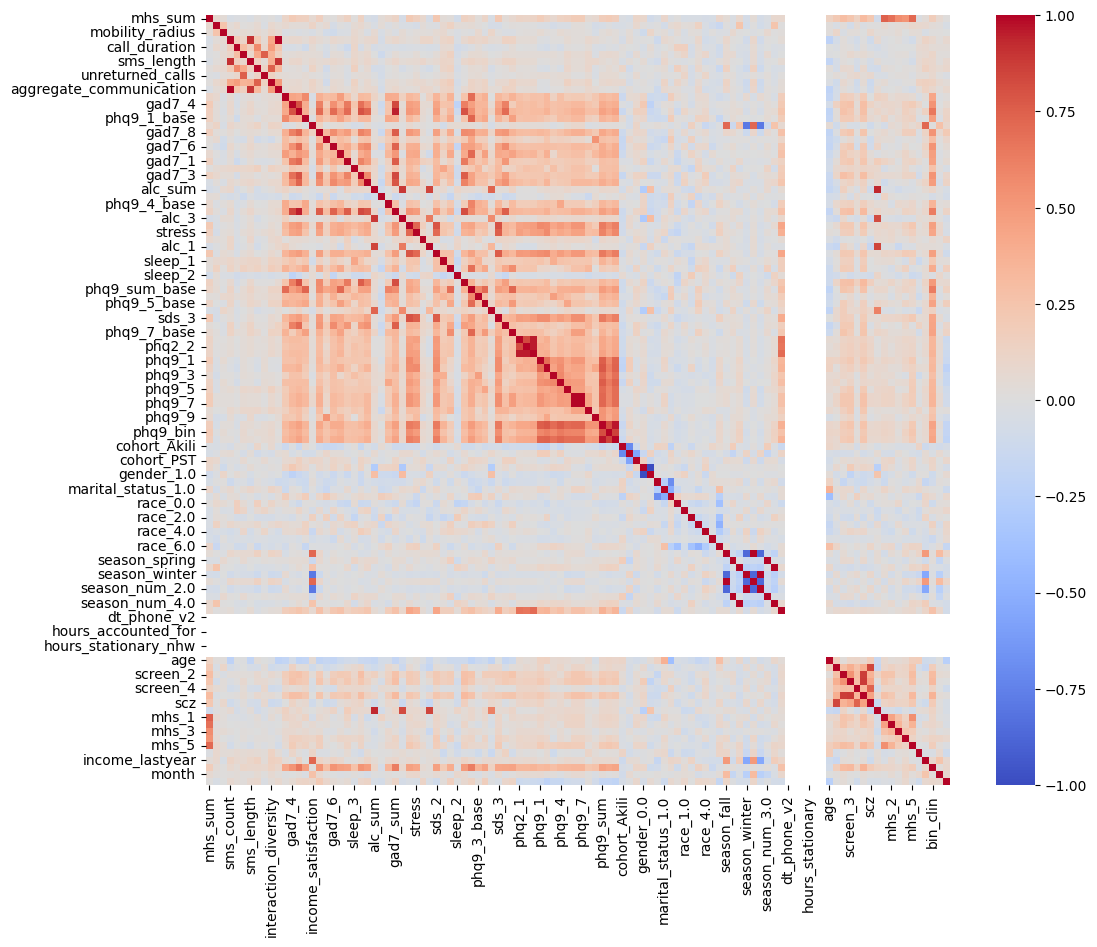

58


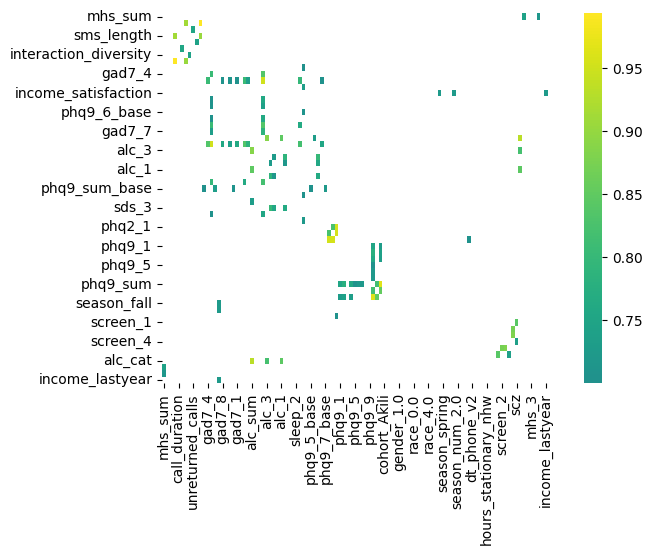

9


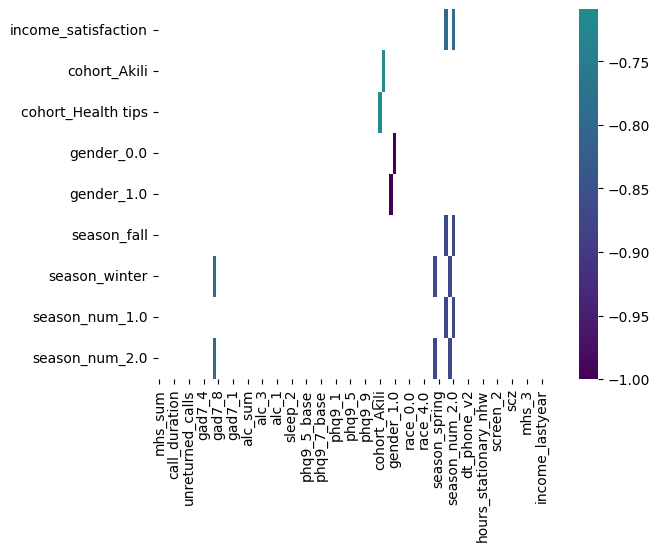

v2_day


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_52046/4082842400.py:13: DtypeWarning: Columns (111) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))


129


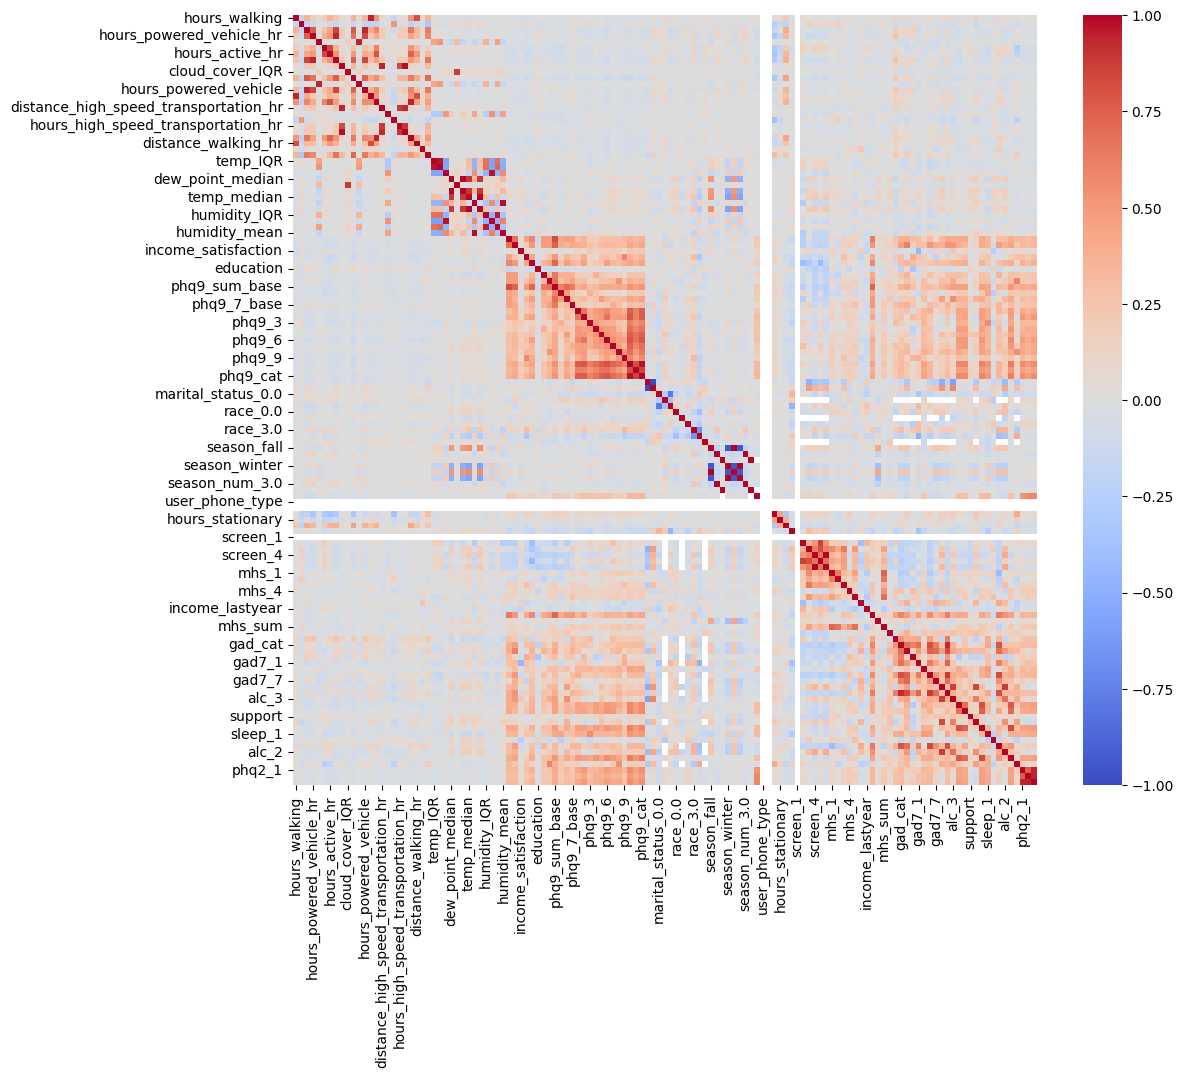

70


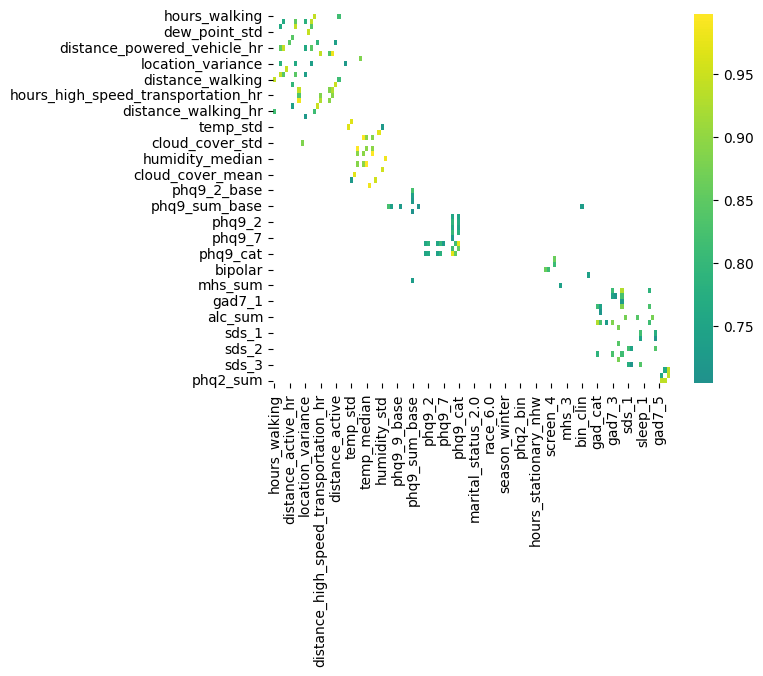

8


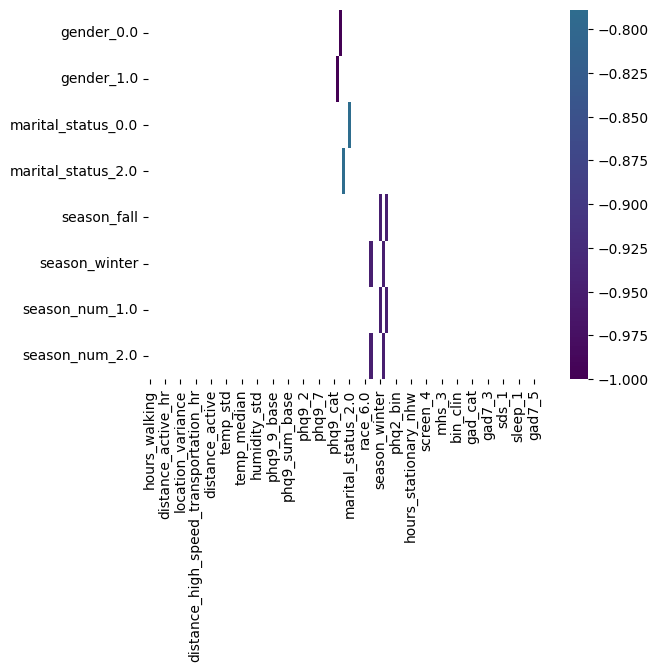

v1_week
122


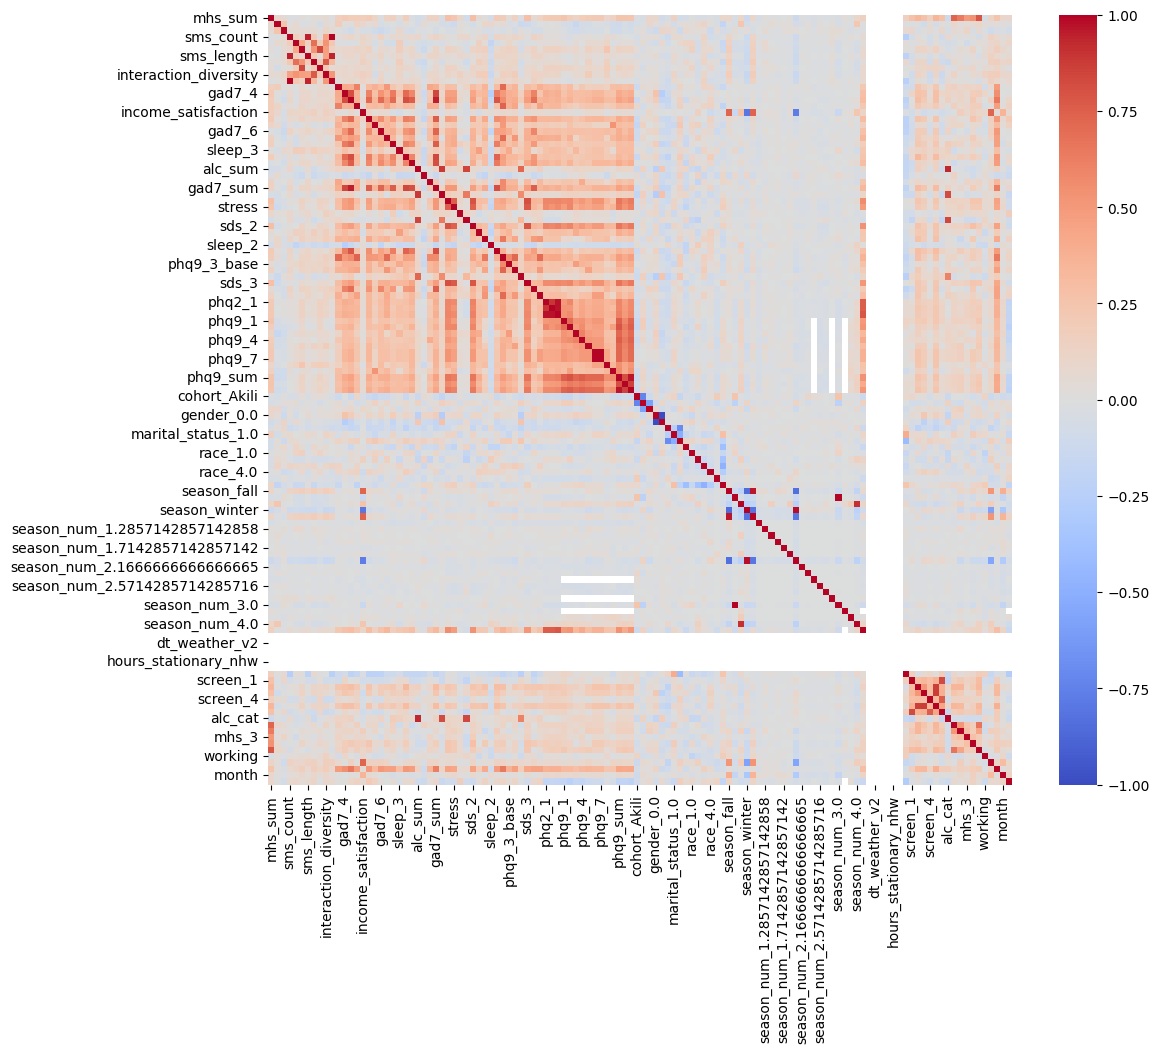

63


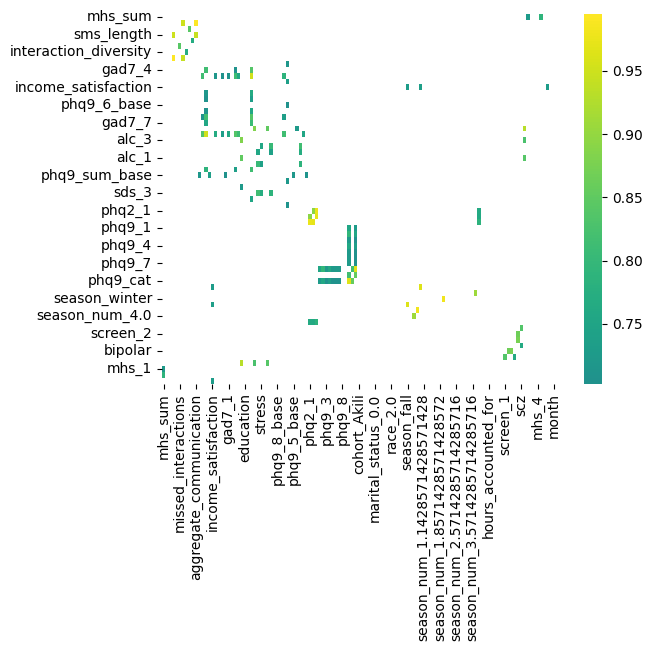

9


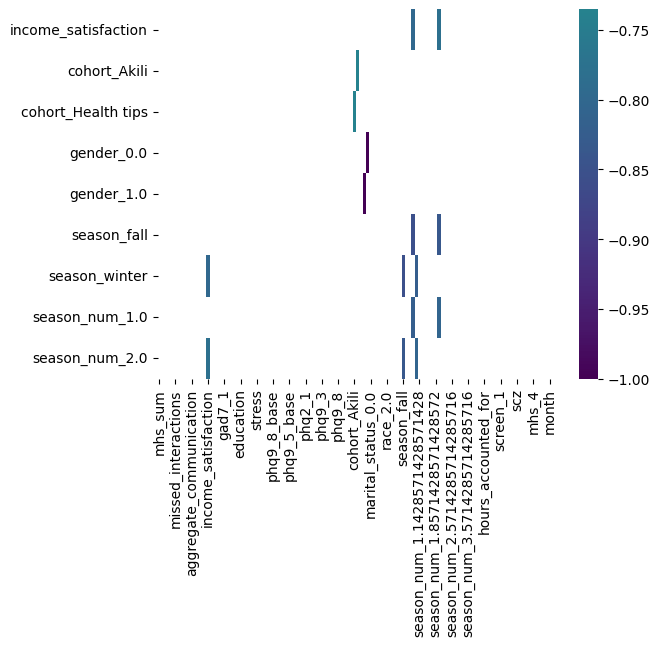

v2_week
149


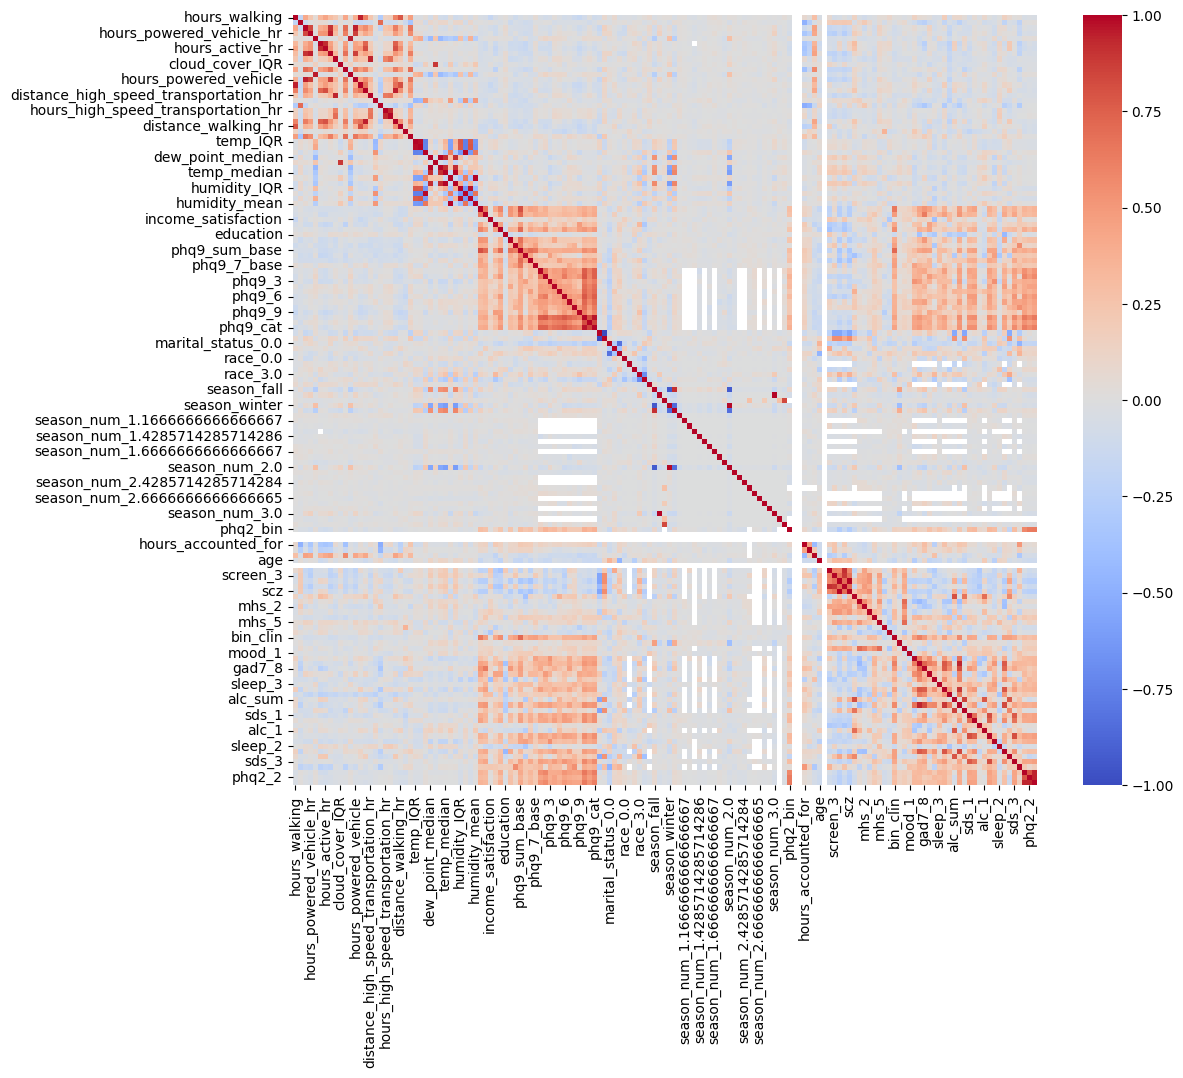

76


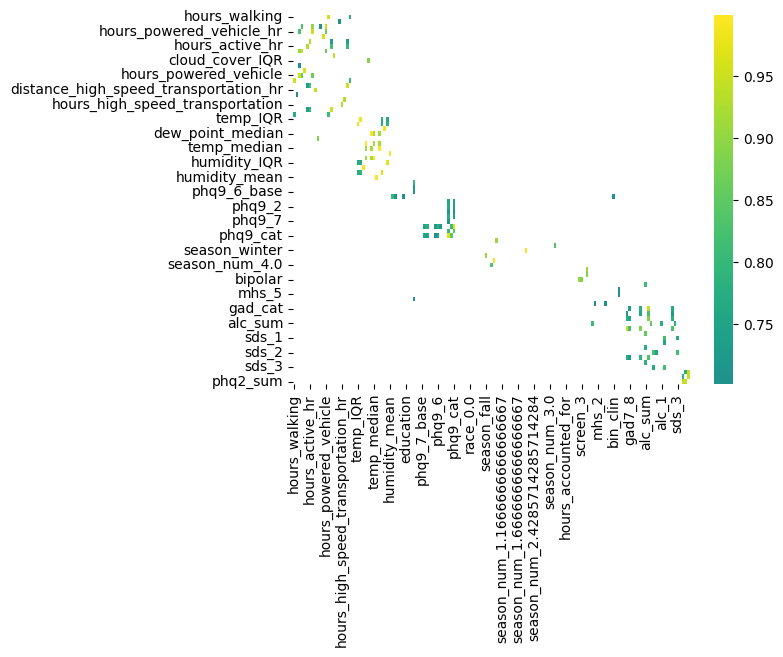

12


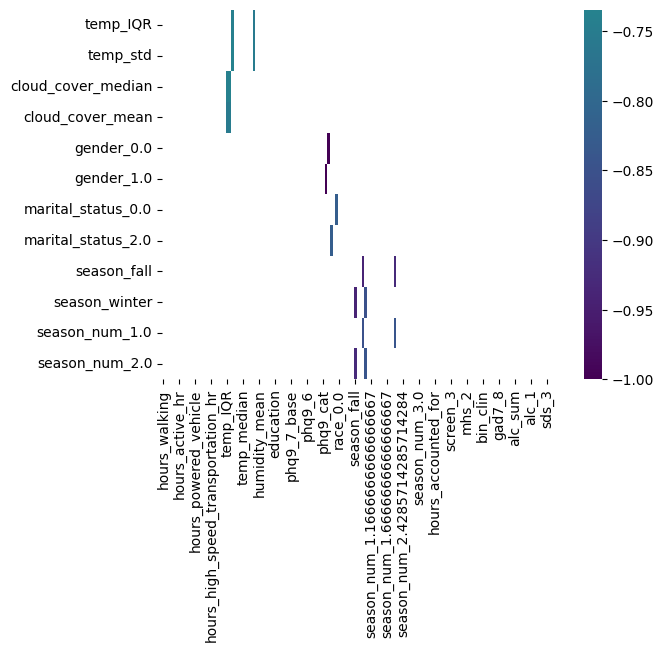

In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [50, 100, 200]
colors = sns.color_palette("colorblind")
target = 'target__target_phq2_sum'
groupby = 'num_id'

ccs = {}

for name in ['v1_day','v2_day','v1_week','v2_week']:
	print(name)
	ccs[name]={}
	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))
	df = df.sort_values(by='day')
	df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col or '_nan' in col or '_indicator' in col or col in id_columns or 'num_id' in col or 'cat_' in col])
	corr = df.select_dtypes(include=('int64','float64')).corr()
	print(len(corr))
	plt.figure(figsize=(12, 10))  # width=12, height=10 inches
	sns.heatmap(corr, cmap="coolwarm", center=0)
	plt.show()


	pos_corr = corr.where(corr>0.7)
	pos_corr = pos_corr.where(pos_corr!=1)
	pos_corr=pos_corr.dropna(how='all')	
	if len(pos_corr)>0:
		print(len(pos_corr))
		sns.heatmap(pos_corr, cmap="viridis", center=0.7)
		plt.show()

		
	neg_corr = corr.where(corr<-0.7)
	neg_corr = neg_corr.where(neg_corr!=1)
	neg_corr=neg_corr.dropna(how='all')
	if len(neg_corr)>0:
		print(len(neg_corr))
		sns.heatmap(neg_corr, cmap="viridis", center=-0.7)
		plt.show()







	

	

# Exactly what we'd expect

- Weather cols are correlated
- Aggregate features are correlated with those features which comprise it
- Multiple questions in the same questionnaire (phq2, phq9) are correlated with each other
- Questionnaires correlated with baseline of those same questionnaires

## Questions:

### SDS
- sds_1 	The symptoms have disrupted your work/school
- sds_2 	The symptoms have disrupted your social life / leisure activities
- sds_3 	The symptoms have disrupted your family life / home responsibilities
- stress 	In the last week, how much were you set back by stressful events or personal problems such as work, home, social, health, or financial problems?
- support In the past week, how much support have you received from friends, relatives, co-workers, etc., as a percentage of the amount you needed to cope?
	* *0 = not at all, 3 = Mildly, 6 = Moderately, 9 = Severely*

### Sleep
- sleep_1 	Thinking about your time in bed at night, over the past week, on average how long did it take you to fall asleep?
- sleep_3 	Thinking about your time in bed at night, over the past week, on average how long did you lie awake after having been asleep?
	* *1 = 0 - 15 minutes, 2 = 16 - 30 minutes, 3 = 31 - 60 minutes, 4 = 61 - 90 minutes, 5 = 91 - 120 minutes, 6 = More than 120 minutes*
- sleep_2 	Thinking about your time in bed at night, over the past week, on average how long were you actually asleep?
	* *1 = 5-6 hours, 2 = 6-7 hours, 3 = 7-8 hours, 4 = Less than 5 hours, 5 = More than 8 hours*

### Mental Health Services
- mhs_1 	An answer to, 'Do you see a psychiatrist for mental health or substance abuse treatment?'
- mhs_2 	An answer to, 'Do you see a psychologist, social worker, or other counselors for mental health or substance abuse treatment? '
- mhs_3 	An answer to, 'Do you attend any groups for mental health or substance abuse treatment?'
- mhs_4 	An answer to, ' Are you reading any self-help books for mental health or substance abuse treatment?'
- mhs_5 	An answer to, 'Are you taking any medications for mental health problems? 
	* *-1 = Decline, 0 = No, 1 = Yes* 

### Mood
- mood_1    'Since beginning this study, how would you describe the change (if any) in ACTIVITY LIMITATIONS, SYMPTOMS, EMOTIONS, and OVERALL QUALITY OF LIFE, related to your mood? '
	* *1 = No change, 2 = Almost the same, 3 = A little better, 4 = Somewhat better, 5 = Much better, 6 = Very much better*
	

Run on: Mon 25 May 2026, 11:26AM
################### MOOD CHANGE: -1 ###################


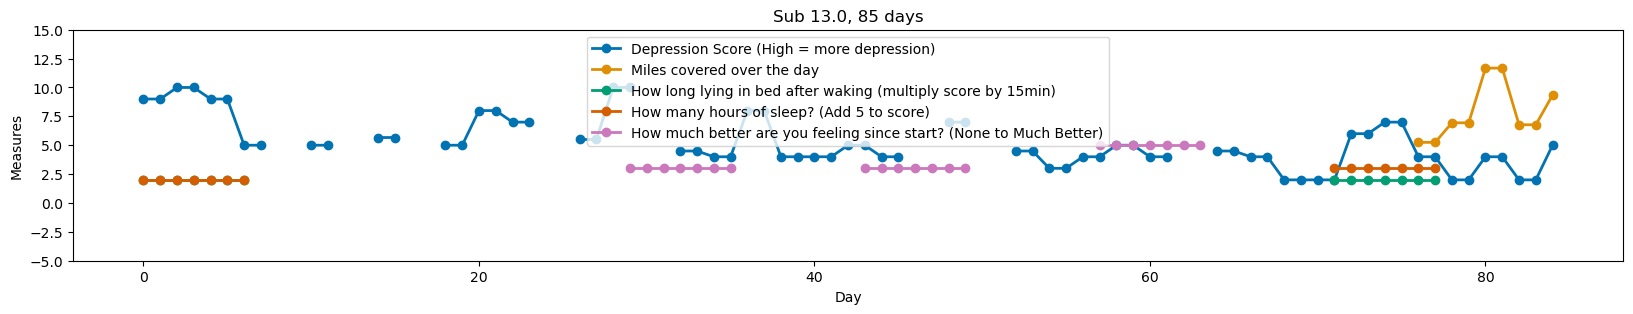

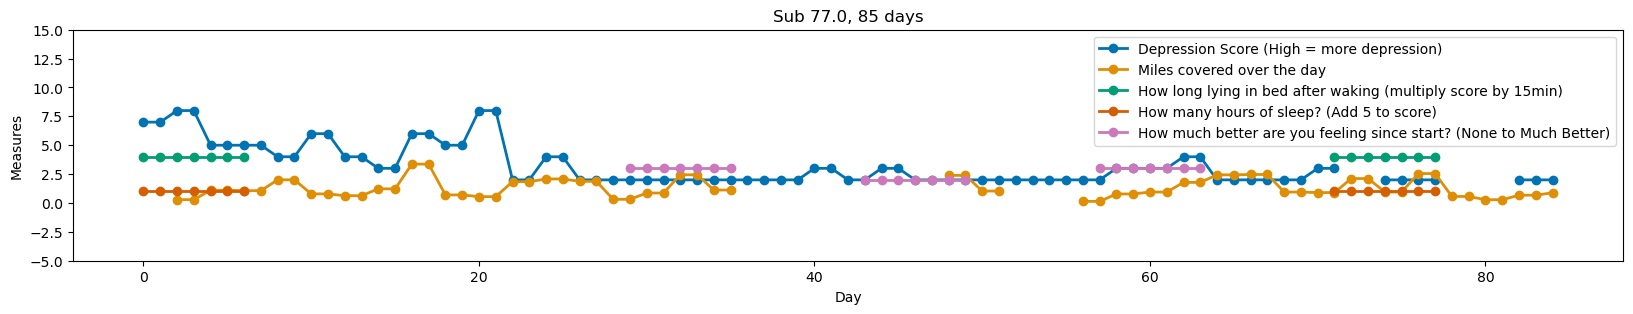

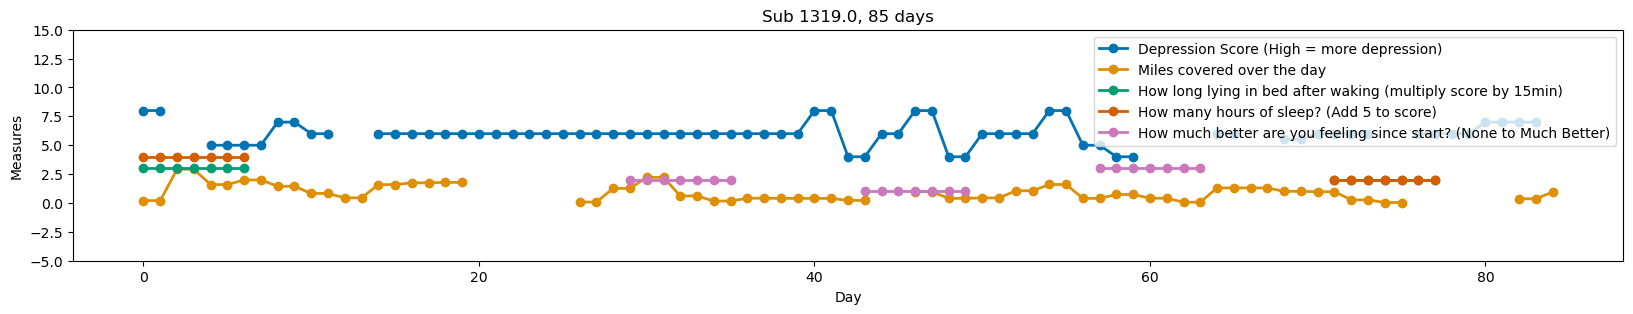

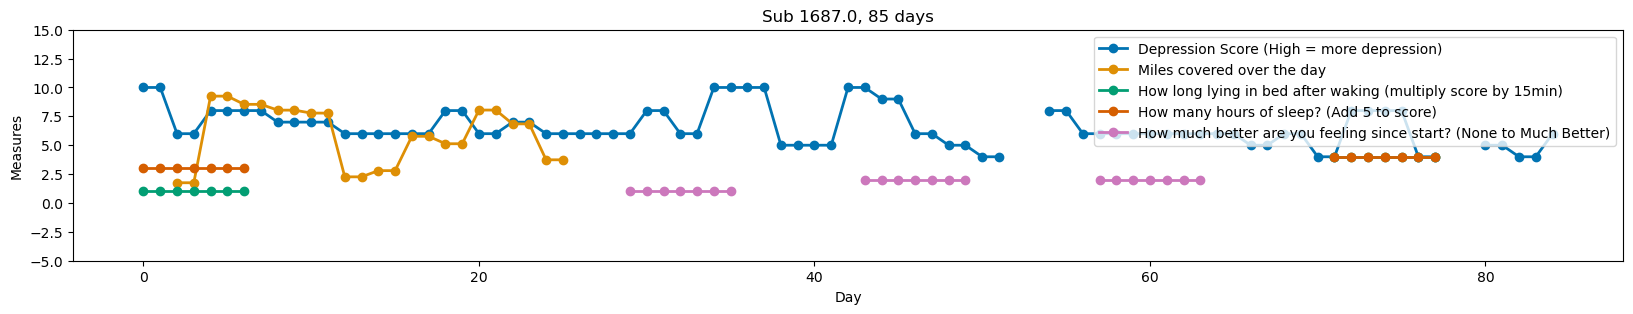

################### MOOD CHANGE: 0 ###################


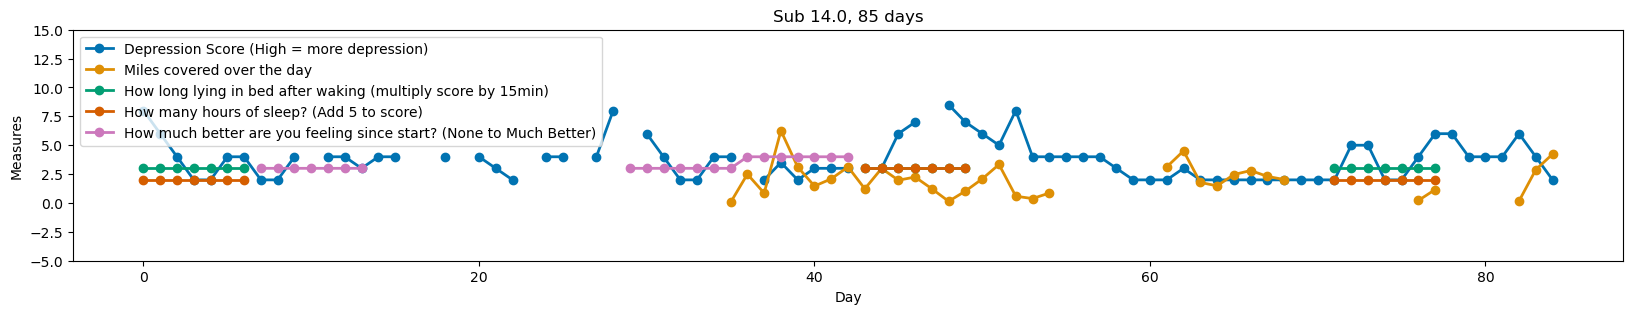

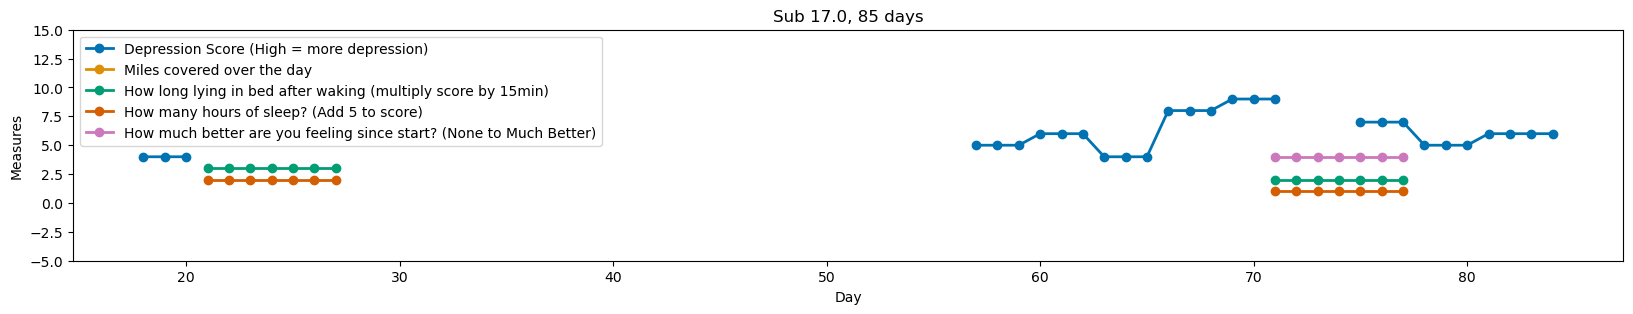

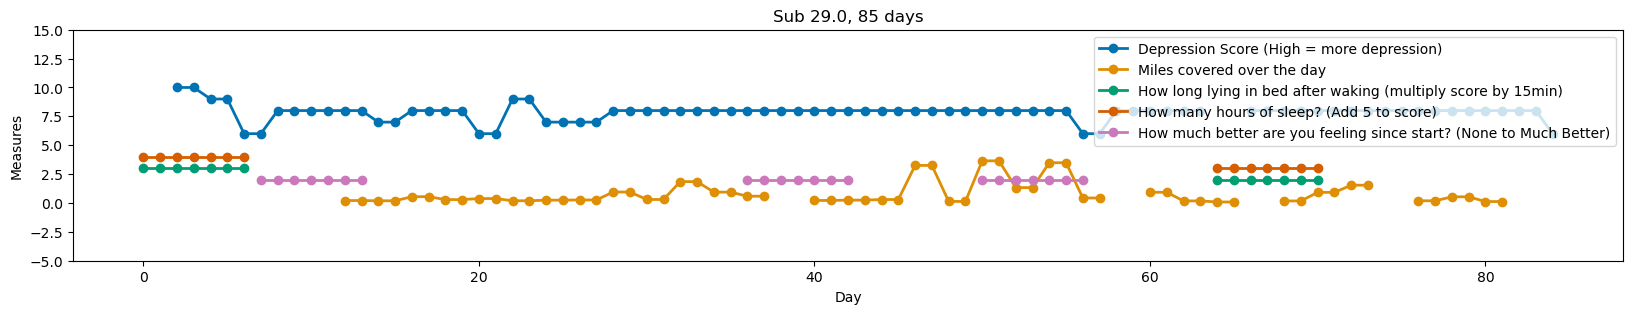

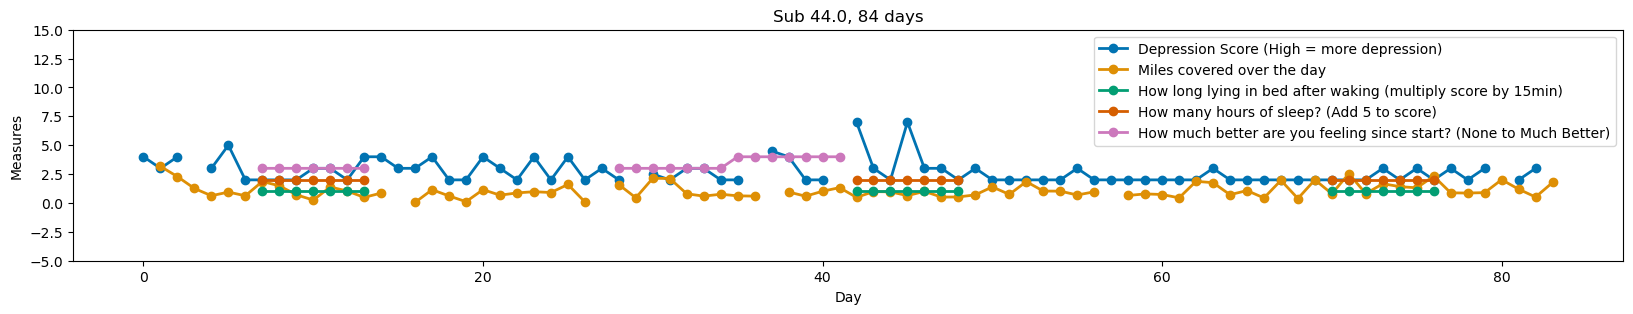

################### MOOD CHANGE: 1 ###################


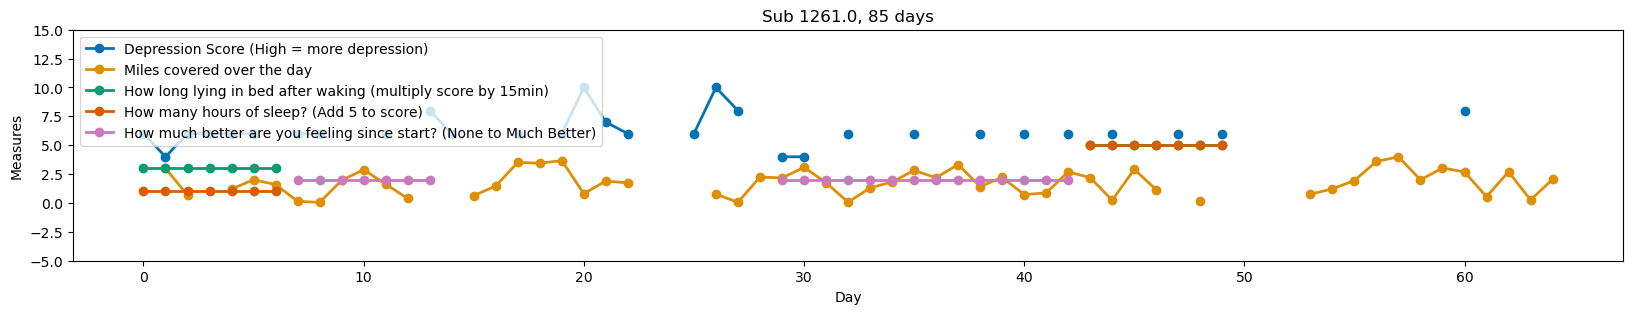

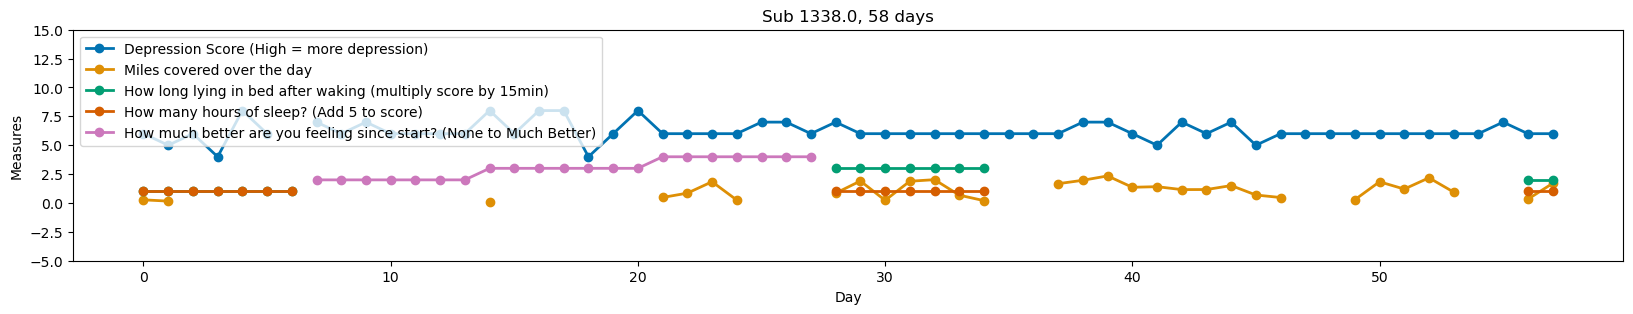

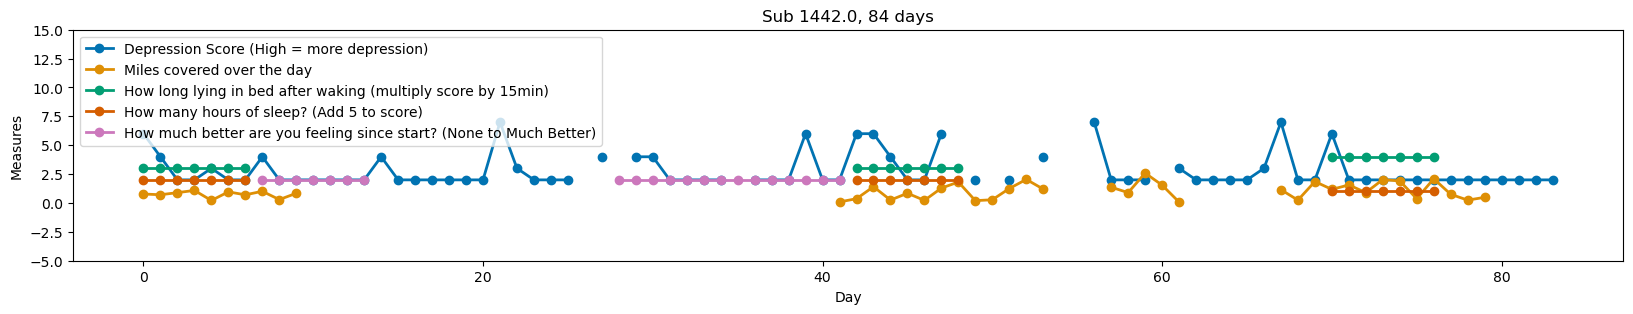

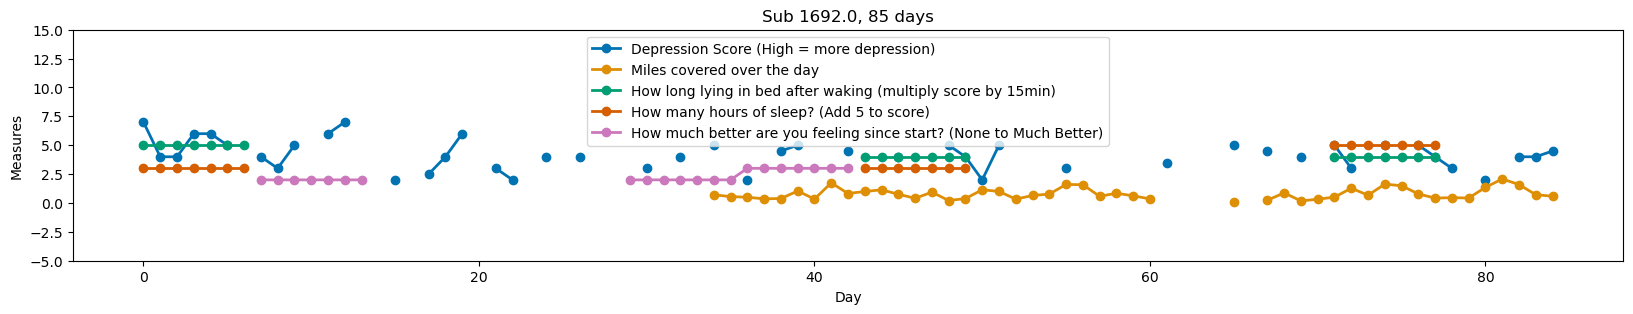

In [5]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")

#demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_clean.csv'))
phq9_end_df = pd.read_csv(os.path.join(outputs_dir, f'phq9sum_6wks.csv'))

strong_corrs = {}
col1 = 'phq2_sum'
col2 = 'mobility'
col3 = 'sleep_3'
col4 = 'sleep_2'
col5 = 'mood_1'


for name in ['v1_day']:
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_outcomes.csv'))
	for mood, mood_df in phq9_end_df.groupby('depression_change_bin'):
		print(f'################### MOOD CHANGE: {mood} ###################')
		sub_count=0
		for sub in mood_df['num_id']:
			sub_df = df[df['num_id']==sub]
			sub_df_clean = sub_df.sort_values('day', ascending=True)
			days = len(sub_df_clean)
			if days > 20:
				sub_count+=1

				
				if sub_count<5:
					fig, ax = plt.subplots(figsize=(20, 3))
					ax.set_ylim(-5,15)
					sub_df_clean.plot(
						x='day',
						y=col1,
						color=colors[0],
						marker='o',
						label=f"Depression Score (High = more depression)",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col2,
						color=colors[1],
						marker='o',
						label=f"Miles covered over the day",
						linewidth=2,
						ax=ax
					)
			
					sub_df_clean.plot(
						x='day',
						y=col3,
						color=colors[2],
						marker='o',
						label=f"How long lying in bed after waking (multiply score by 15min)",
						linewidth=2,
						ax=ax
					)

					sub_df_clean.plot(
						x='day',
						y=col4,
						color=colors[3],
						marker='o',
						label=f"How many hours of sleep? (Add 5 to score)",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col5,
						color=colors[4],
						marker='o',
						label=f"How much better are you feeling since start? (None to Much Better)",
						linewidth=2,
						ax=ax
					)


					
					ax.set(
						title=f"Sub {sub}, {days} days",
						xlabel="Day",
						ylabel="Measures",
					)
					ax.legend()
					plt.show()					




				


Run on: Mon 25 May 2026, 11:27AM
################### MOOD CHANGE: -1 ###################


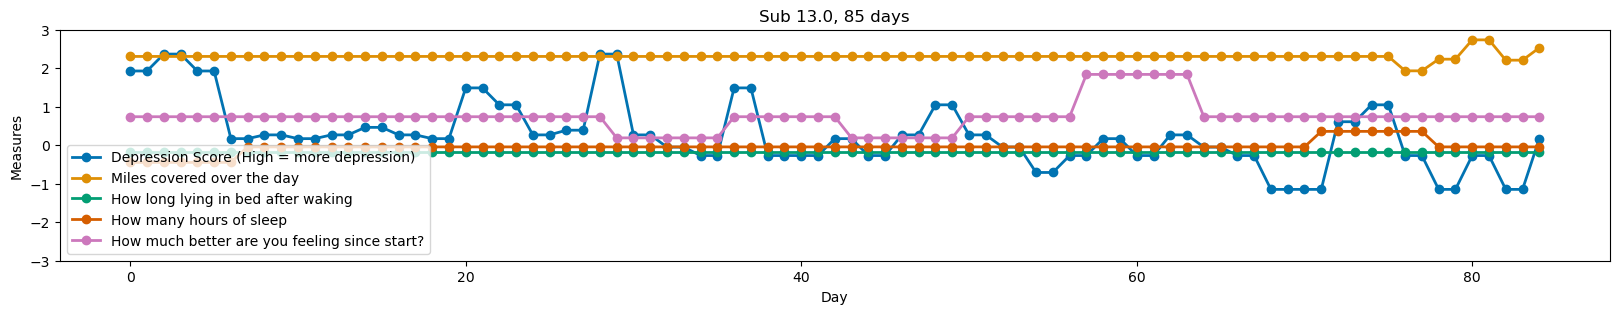

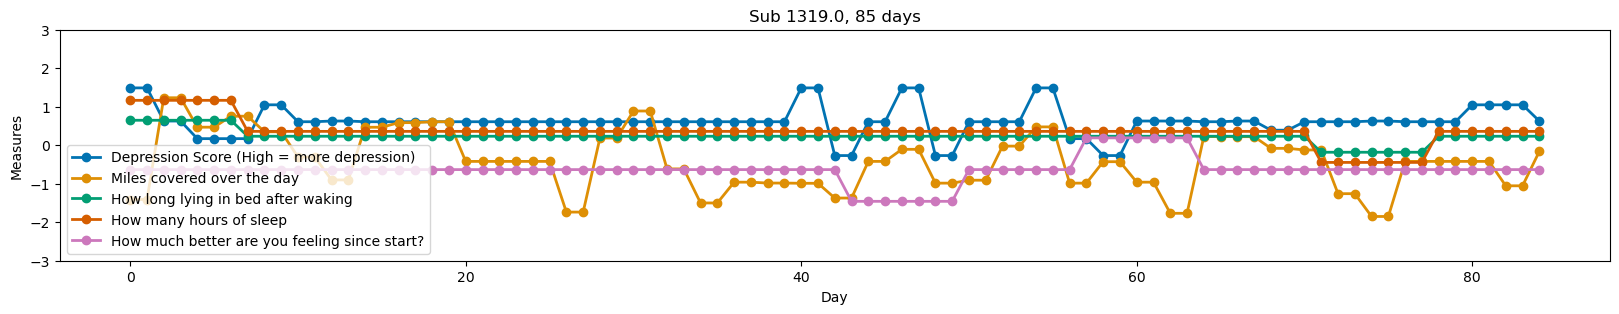

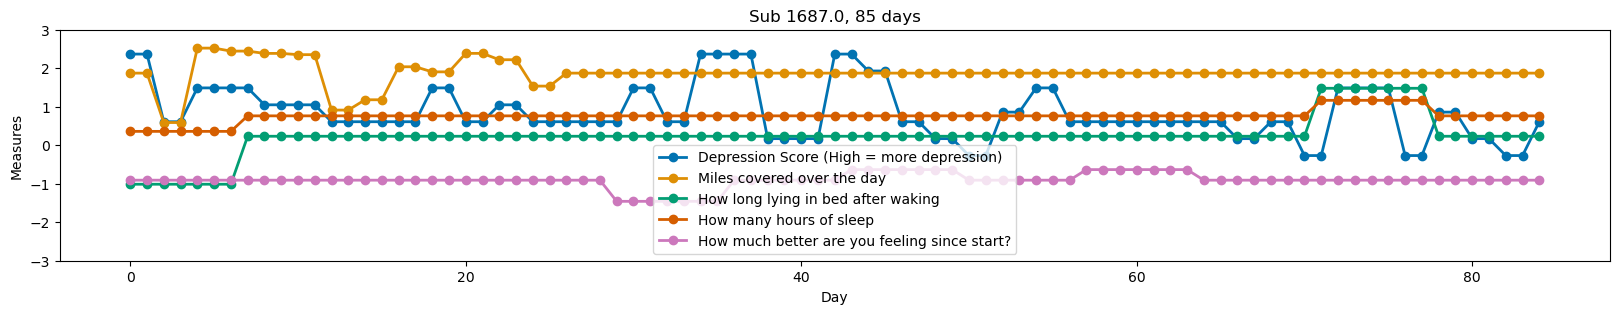

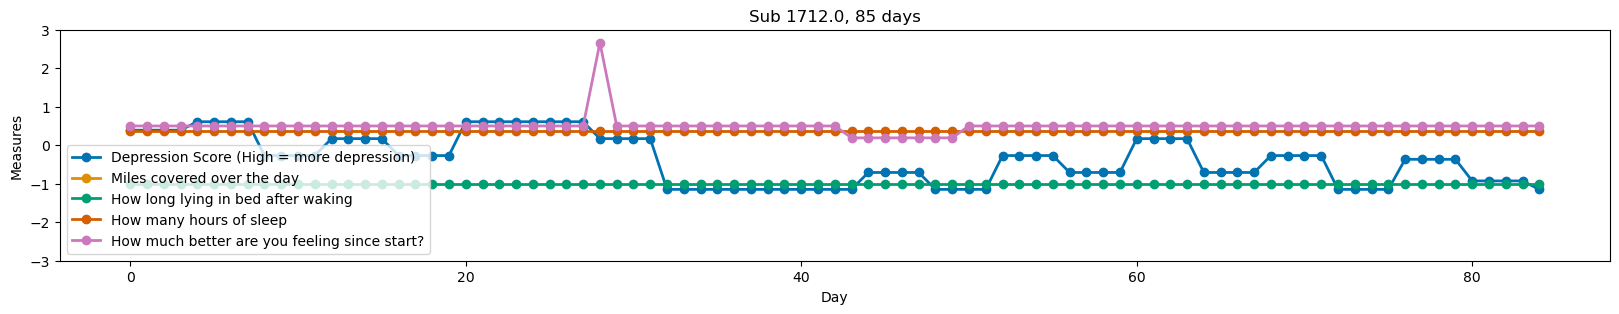

################### MOOD CHANGE: 0 ###################


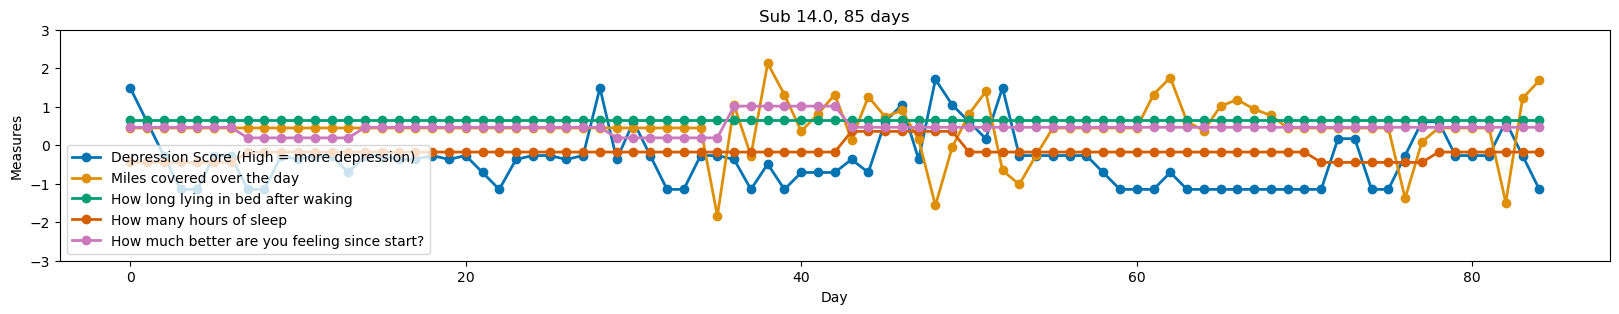

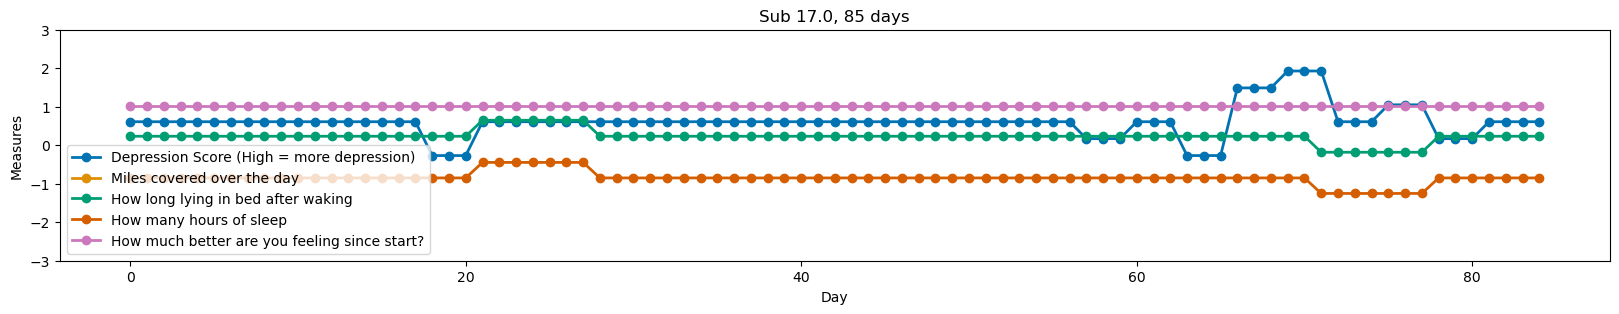

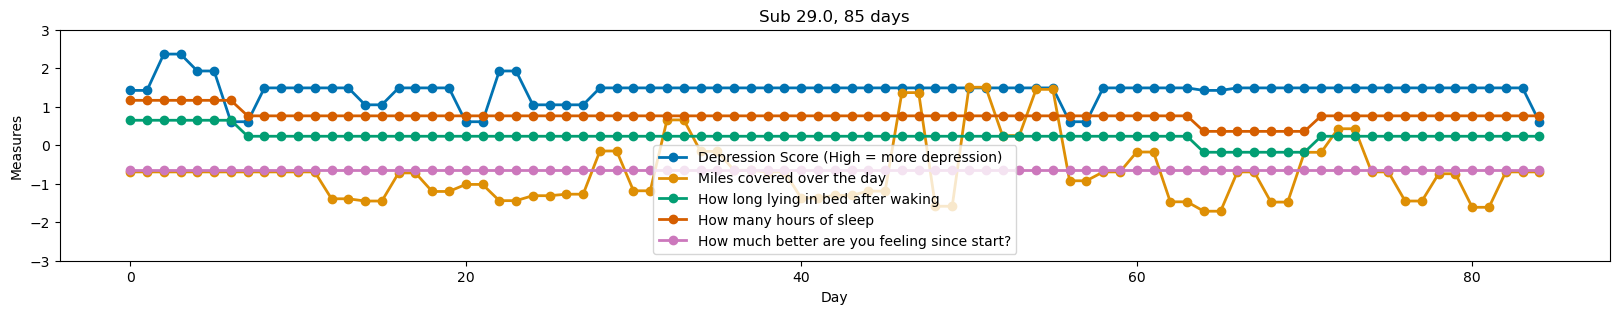

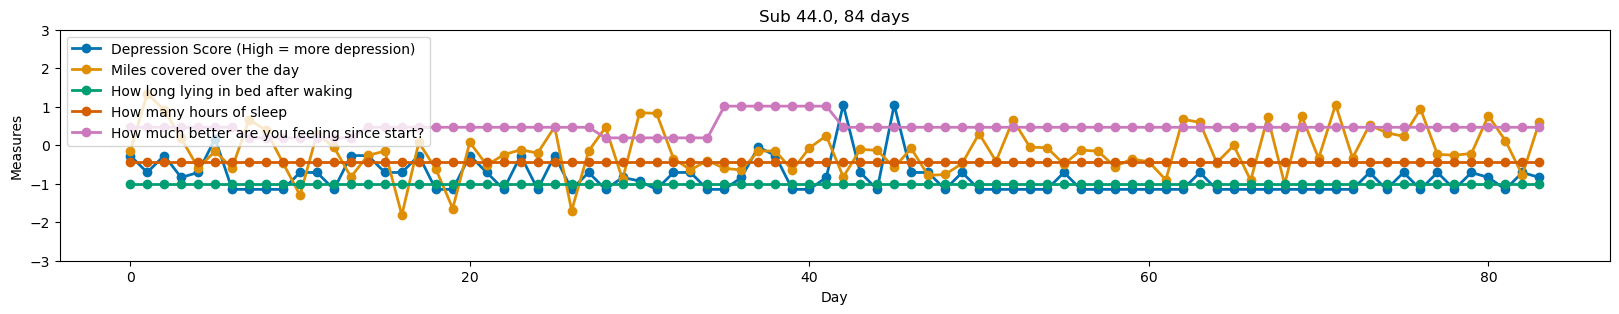

################### MOOD CHANGE: 1 ###################


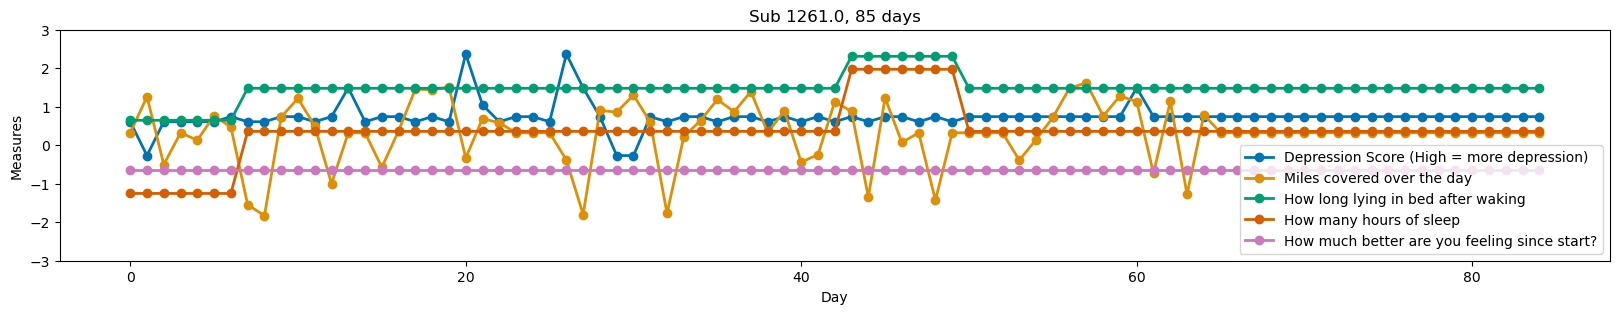

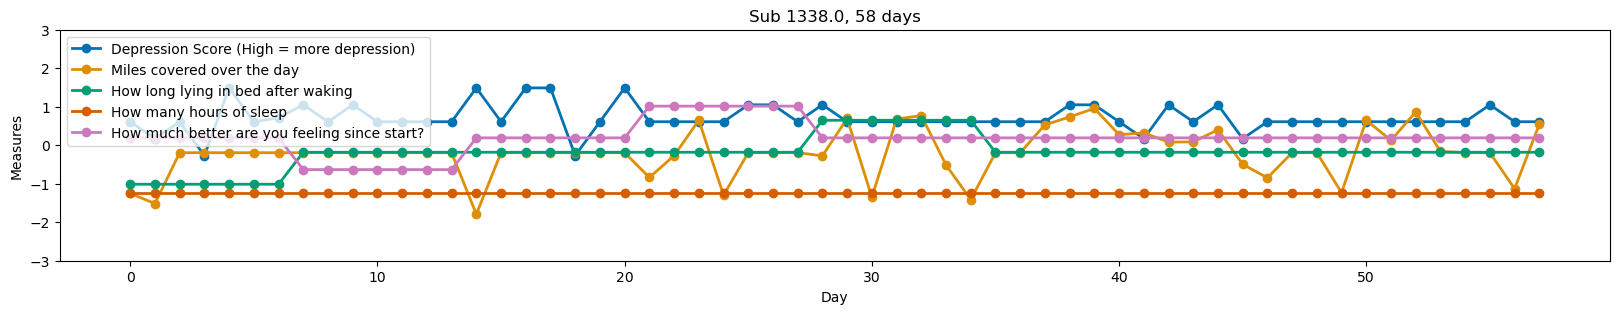

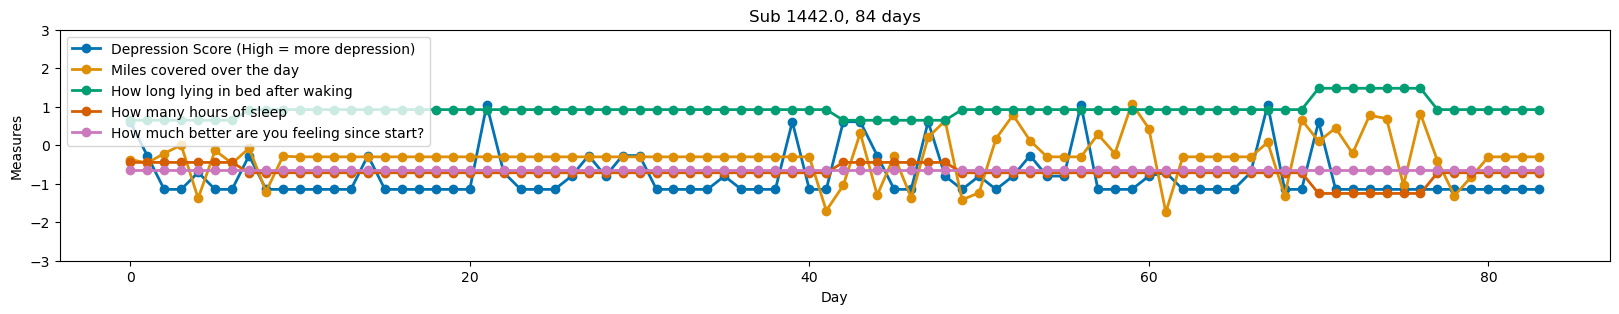

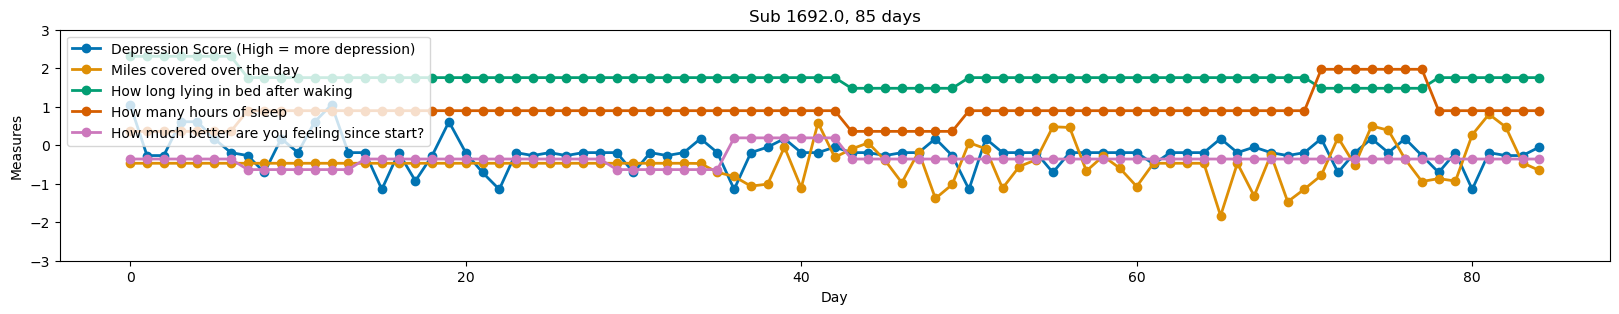

In [7]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")

phq9_end_df = pd.read_csv(os.path.join(outputs_dir, f'phq9sum_6wks.csv'))

strong_corrs = {}
col1 = 'phq2_sum'
col2 = 'mobility'
col3 = 'sleep_3'
col4 = 'sleep_2'
col5 = 'mood_1'


for name in ['v1_day']:
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))
	for mood, mood_df in phq9_end_df.groupby('depression_change_bin'):
		print(f'################### MOOD CHANGE: {mood} ###################')
		sub_count=0
		for sub in mood_df['num_id']:
			sub_df = df[df['num_id']==sub]
			sub_df_clean = sub_df.sort_values('day', ascending=True)
			days = len(sub_df_clean)
			if days > 20:
				sub_count+=1

				
				if sub_count<5:
					fig, ax = plt.subplots(figsize=(20, 3))
					ax.set_ylim(-3,3)
					sub_df_clean.plot(
						x='day',
						y=col1,
						color=colors[0],
						marker='o',
						label=f"Depression Score (High = more depression)",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col2,
						color=colors[1],
						marker='o',
						label=f"Miles covered over the day",
						linewidth=2,
						ax=ax
					)
			
					sub_df_clean.plot(
						x='day',
						y=col3,
						color=colors[2],
						marker='o',
						label=f"How long lying in bed after waking",
						linewidth=2,
						ax=ax
					)

					sub_df_clean.plot(
						x='day',
						y=col4,
						color=colors[3],
						marker='o',
						label=f"How many hours of sleep",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col5,
						color=colors[4],
						marker='o',
						label=f"How much better are you feeling since start?",
						linewidth=2,
						ax=ax
					)


					
					ax.set(
						title=f"Sub {sub}, {days} days",
						xlabel="Day",
						ylabel="Measures",
					)
					ax.legend()
					plt.show()					




				


Run on: Mon 25 May 2026, 11:28AM
################### DEPRESSED AT START?: 0 ###################


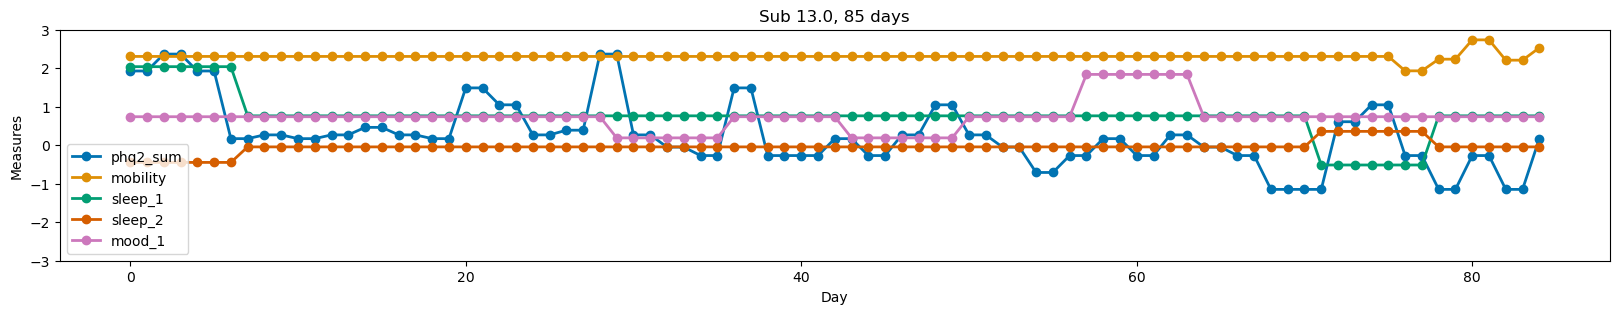

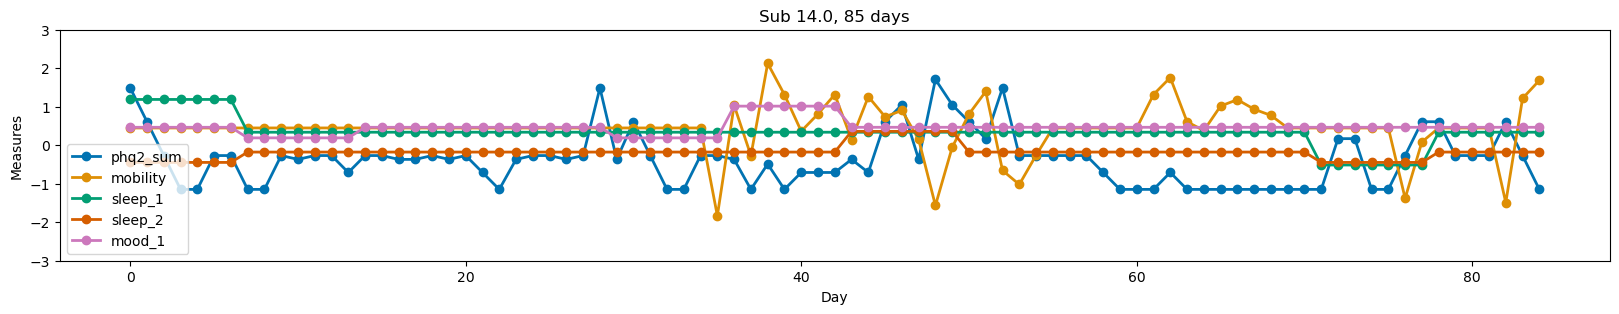

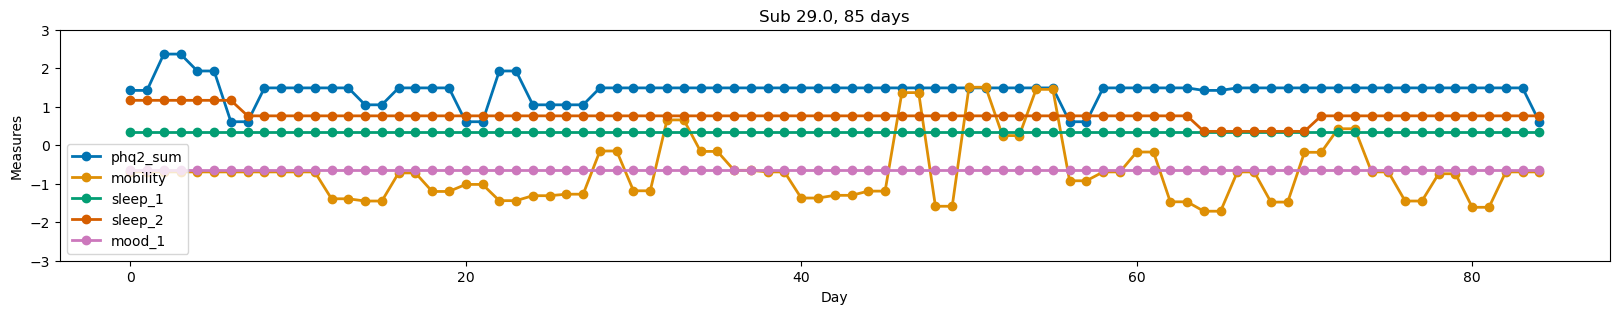

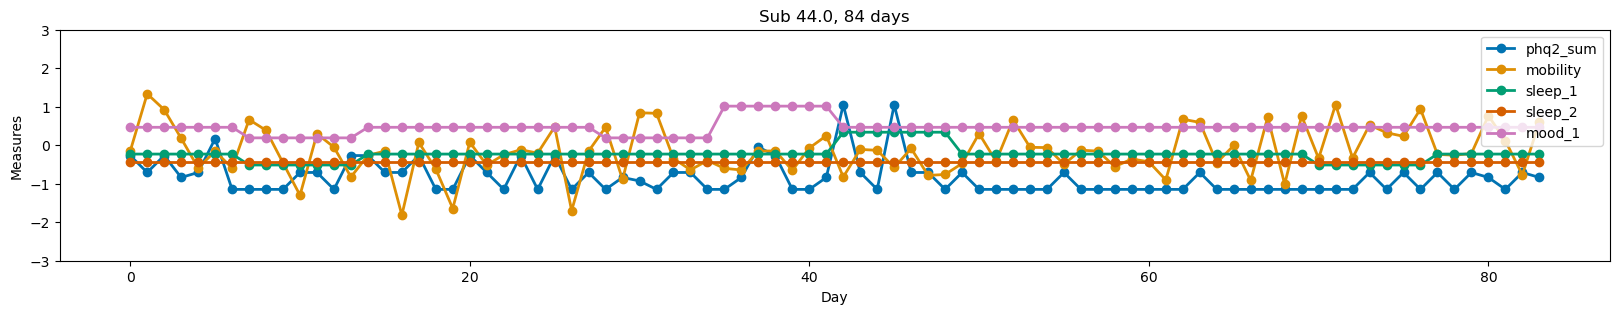

################### DEPRESSED AT START?: 1 ###################


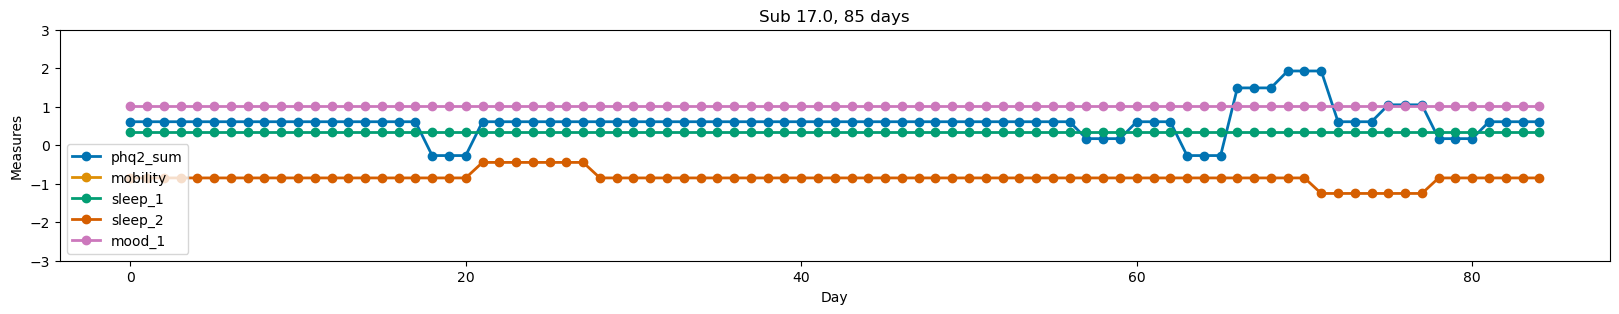

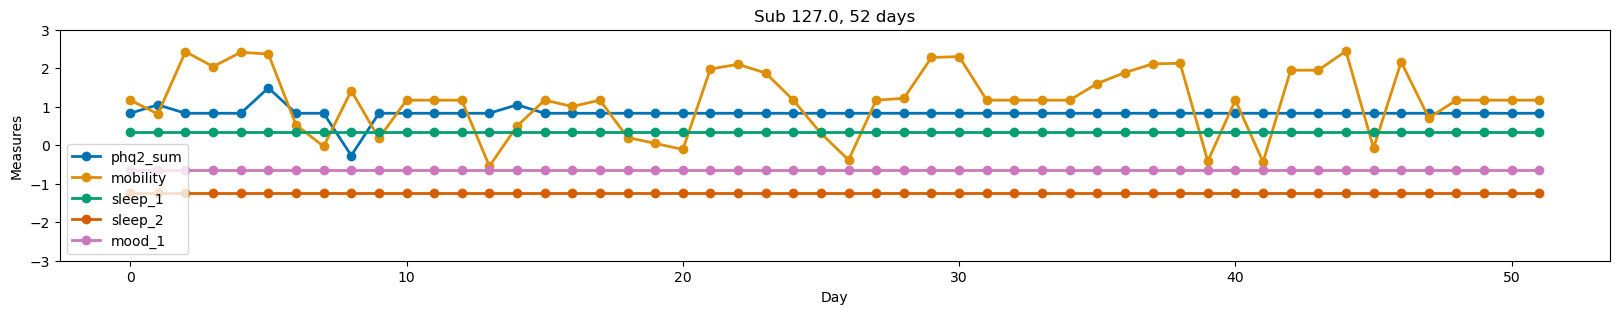

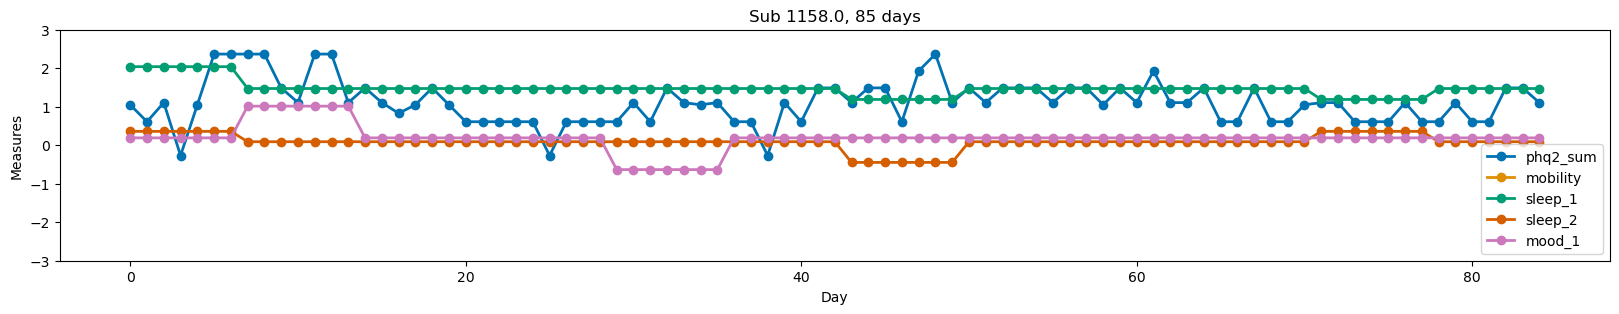

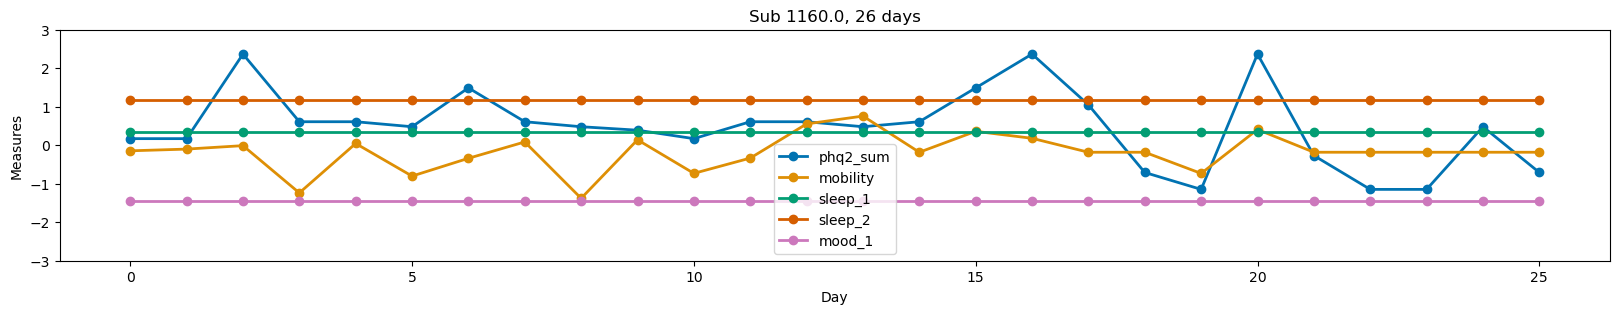

In [8]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")

phq9_end_df = pd.read_csv(os.path.join(outputs_dir, f'phq9sum_6wks.csv'))

strong_corrs = {}
col1 = 'phq2_sum'
col2 = 'mobility'
col3 = 'sleep_1'
col4 = 'sleep_2'
col5 = 'mood_1'


for name in ['v1_day']:
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))
	for mood, mood_df in phq9_end_df.groupby('start_depressed_binary'):
		print(f'################### DEPRESSED AT START?: {mood} ###################')
		sub_count=0
		for sub in mood_df['num_id']:
			sub_df = df[df['num_id']==sub]
			sub_df_clean = sub_df.sort_values('day', ascending=True)
			days = len(sub_df_clean)
			if days > 20:
				sub_count+=1

				
				if sub_count<5:
					fig, ax = plt.subplots(figsize=(20, 3))
					ax.set_ylim(-3, 3)
					sub_df_clean.plot(
						x='day',
						y=col1,
						color=colors[0],
						marker='o',
						label=f"{col1}",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col2,
						color=colors[1],
						marker='o',
						label=f"{col2}",
						linewidth=2,
						ax=ax
					)
			
					sub_df_clean.plot(
						x='day',
						y=col3,
						color=colors[2],
						marker='o',
						label=f"{col3}",
						linewidth=2,
						ax=ax
					)

					sub_df_clean.plot(
						x='day',
						y=col4,
						color=colors[3],
						marker='o',
						label=f"{col4}",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col5,
						color=colors[4],
						marker='o',
						label=f"{col5}",
						linewidth=2,
						ax=ax
					)



					
					ax.set(
						title=f"Sub {sub}, {days} days",
						xlabel="Day",
						ylabel="Measures",
					)
					ax.legend()
					plt.show()

					
				


Run on: Mon 25 May 2026, 11:28AM
################### DEPRESSED AT START?: 0 ###################


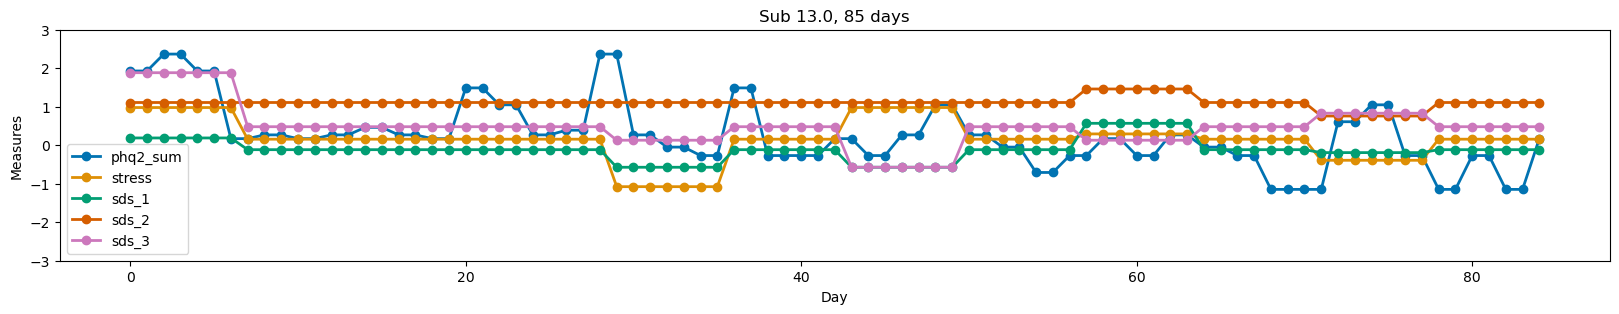

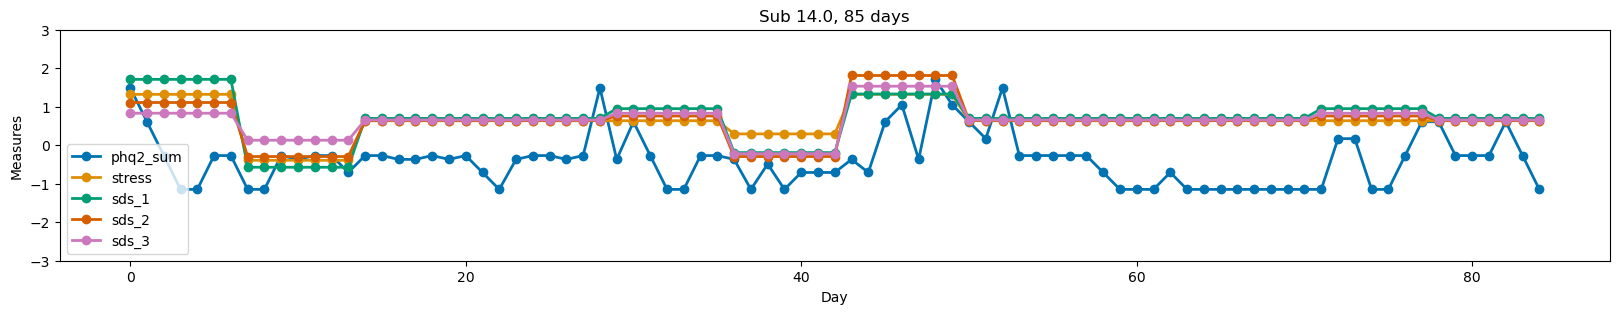

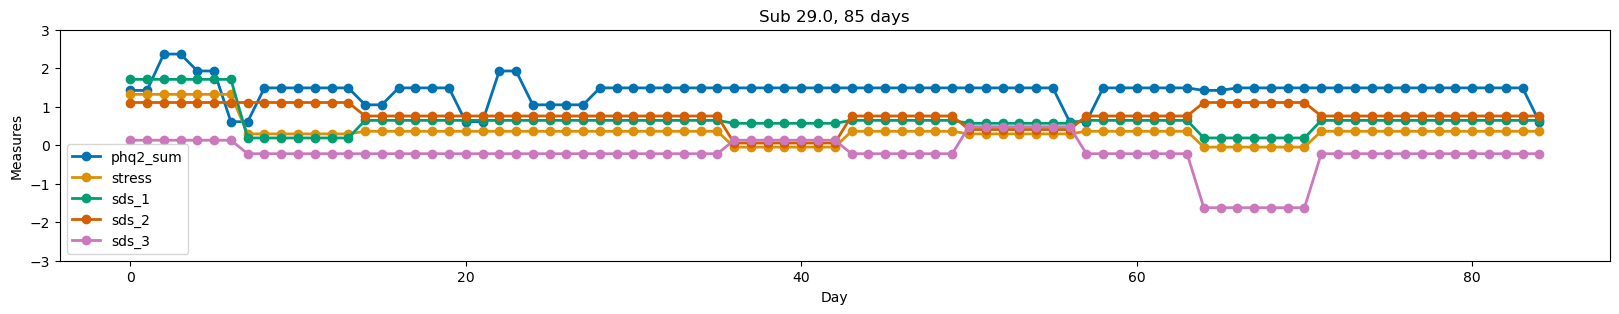

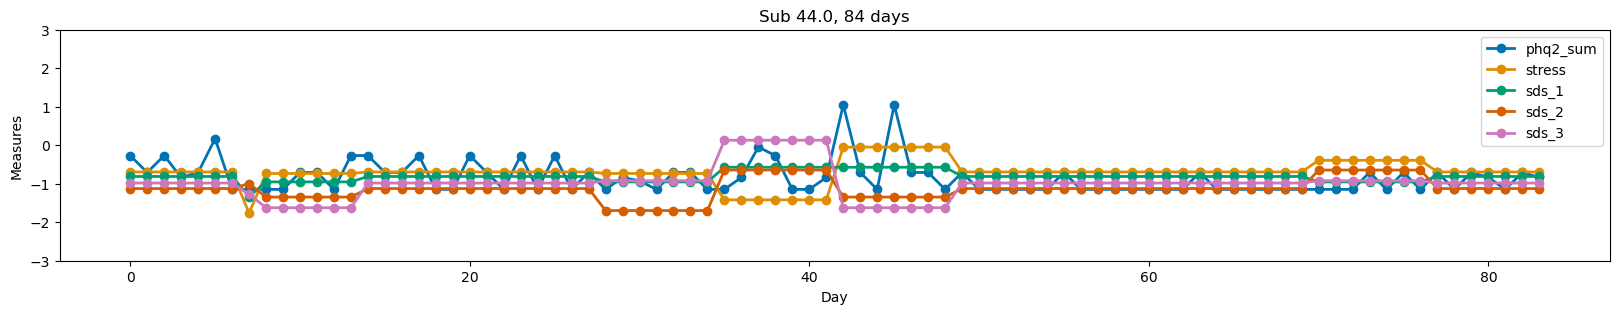

################### DEPRESSED AT START?: 1 ###################


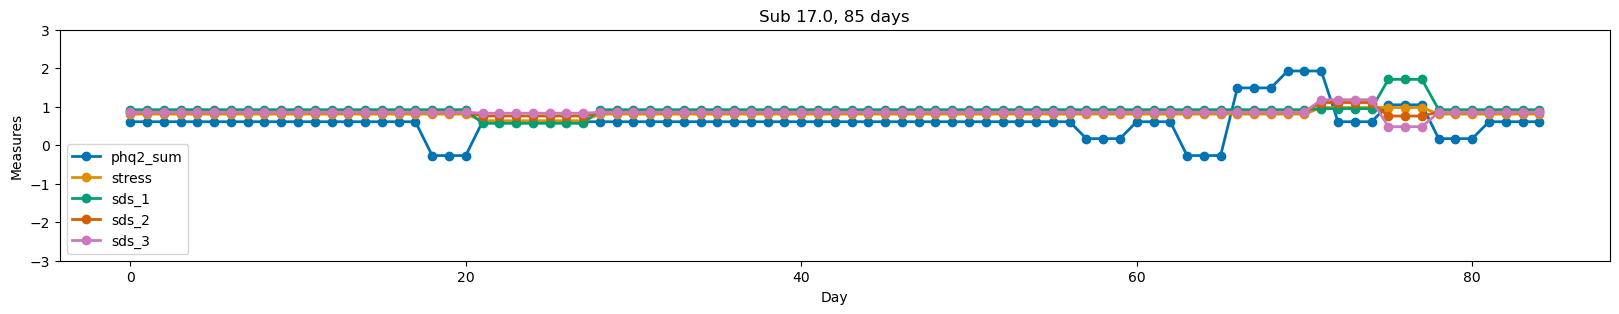

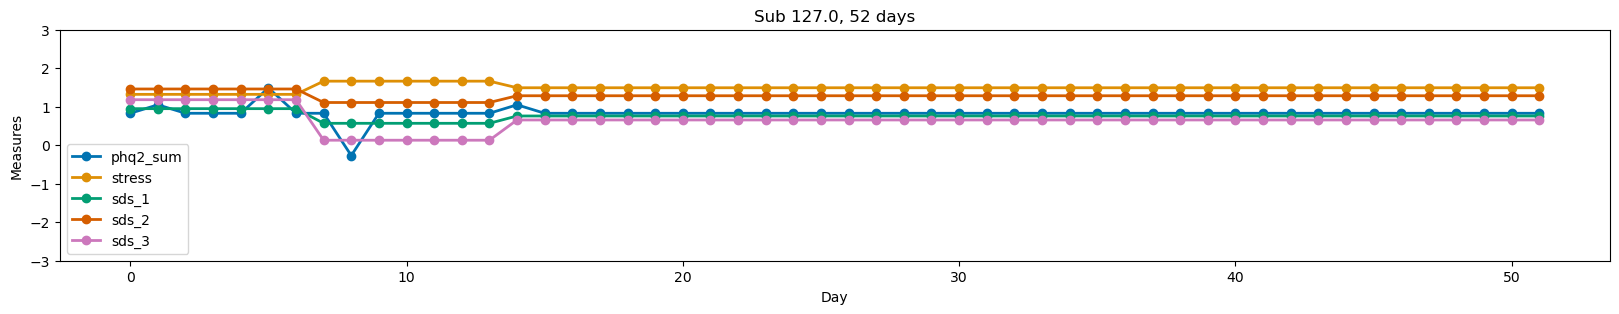

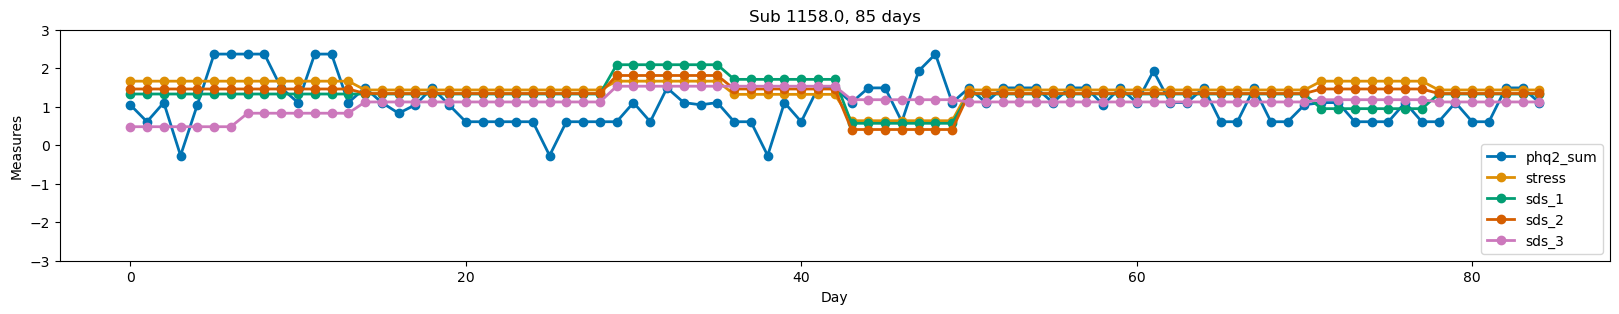

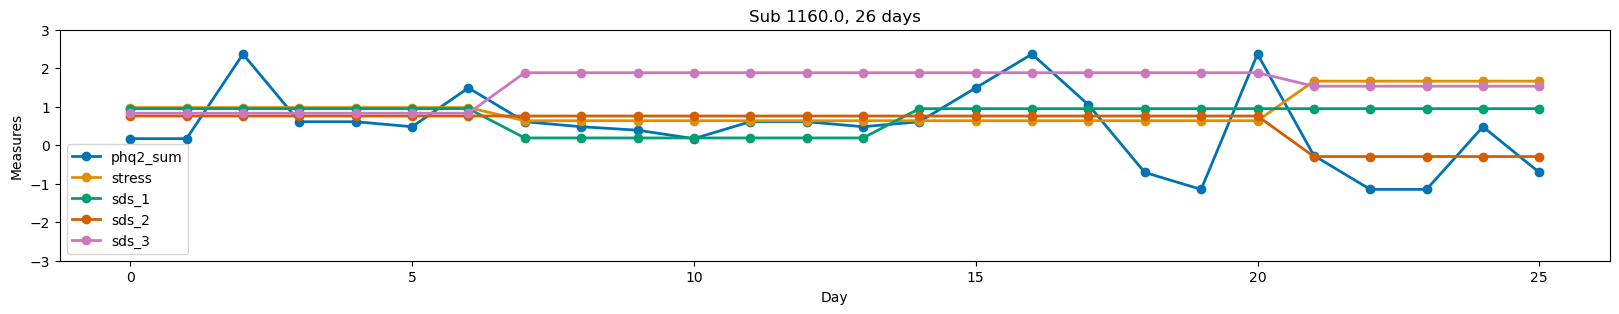

In [9]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
max_iter_list = [100]
colors = sns.color_palette("colorblind")

phq9_end_df = pd.read_csv(os.path.join(outputs_dir, f'phq9sum_6wks.csv'))

strong_corrs = {}
col1 = 'phq2_sum'
col2 = 'stress'
col3 = 'sds_1'
col4 = 'sds_2'
col5 = 'sds_3'


for name in ['v1_day']:
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))
	for mood, mood_df in phq9_end_df.groupby('start_depressed_binary'):
		print(f'################### DEPRESSED AT START?: {mood} ###################')
		sub_count=0
		for sub in mood_df['num_id']:
			sub_df = df[df['num_id']==sub]
			sub_df_clean = sub_df.sort_values('day', ascending=True)
			days = len(sub_df_clean)
			if days > 20:
				sub_count+=1

				
				if sub_count<5:
					fig, ax = plt.subplots(figsize=(20, 3))
					ax.set_ylim(-3, 3)
					sub_df_clean.plot(
						x='day',
						y=col1,
						color=colors[0],
						marker='o',
						label=f"{col1}",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col2,
						color=colors[1],
						marker='o',
						label=f"{col2}",
						linewidth=2,
						ax=ax
					)
			
					sub_df_clean.plot(
						x='day',
						y=col3,
						color=colors[2],
						marker='o',
						label=f"{col3}",
						linewidth=2,
						ax=ax
					)

					sub_df_clean.plot(
						x='day',
						y=col4,
						color=colors[3],
						marker='o',
						label=f"{col4}",
						linewidth=2,
						ax=ax
					)
					
					sub_df_clean.plot(
						x='day',
						y=col5,
						color=colors[4],
						marker='o',
						label=f"{col5}",
						linewidth=2,
						ax=ax
					)



					
					ax.set(
						title=f"Sub {sub}, {days} days",
						xlabel="Day",
						ylabel="Measures",
					)
					ax.legend()
					plt.show()

					
				


# Investigate for Seasonality

################# v1_day ##################


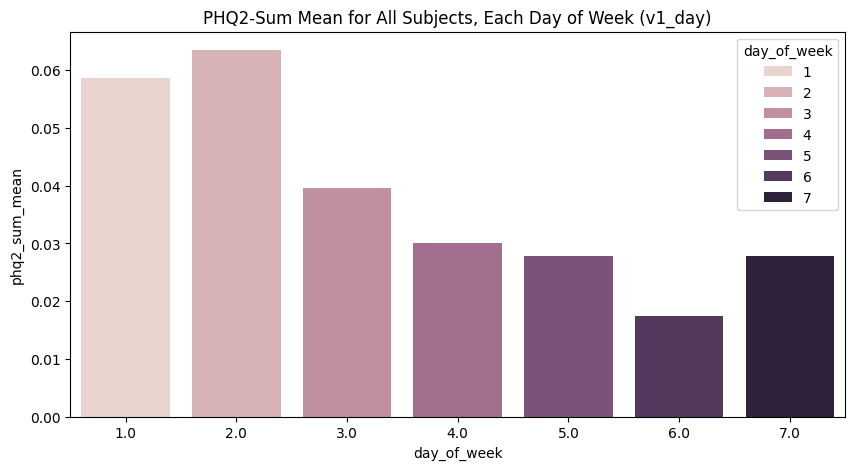

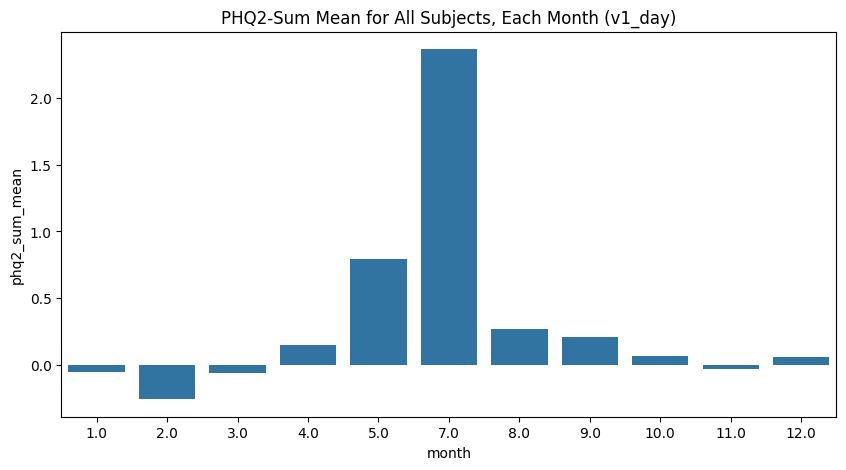

################# v2_day ##################


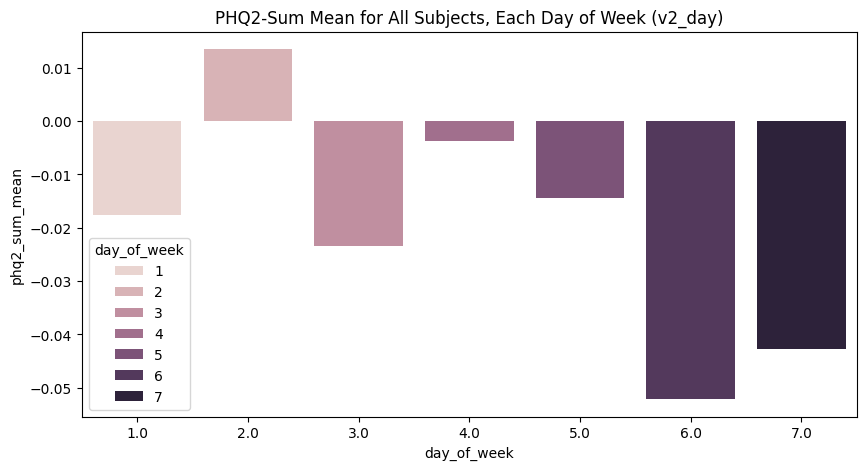

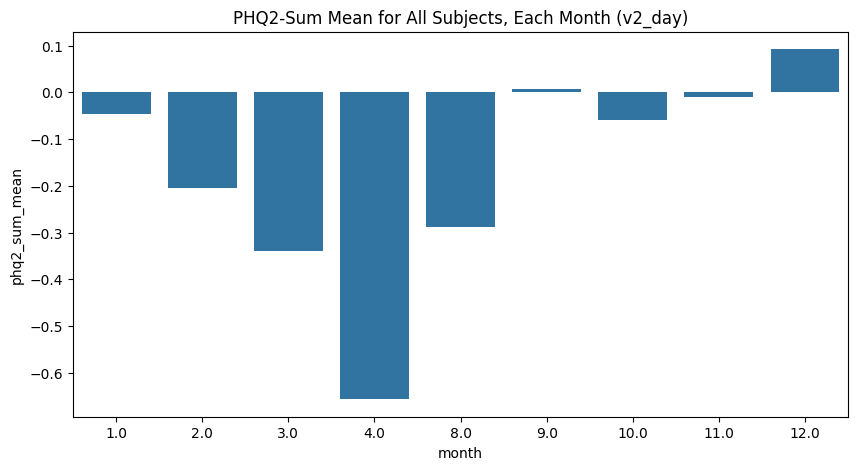

################# v1_week ##################


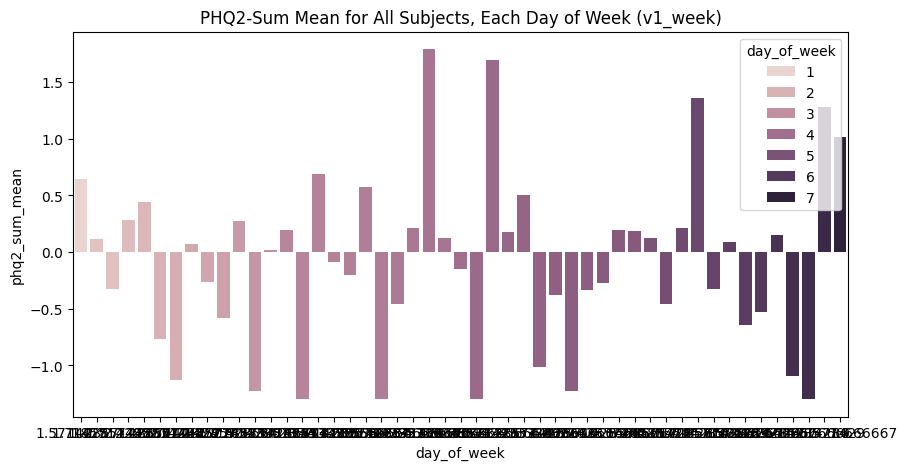

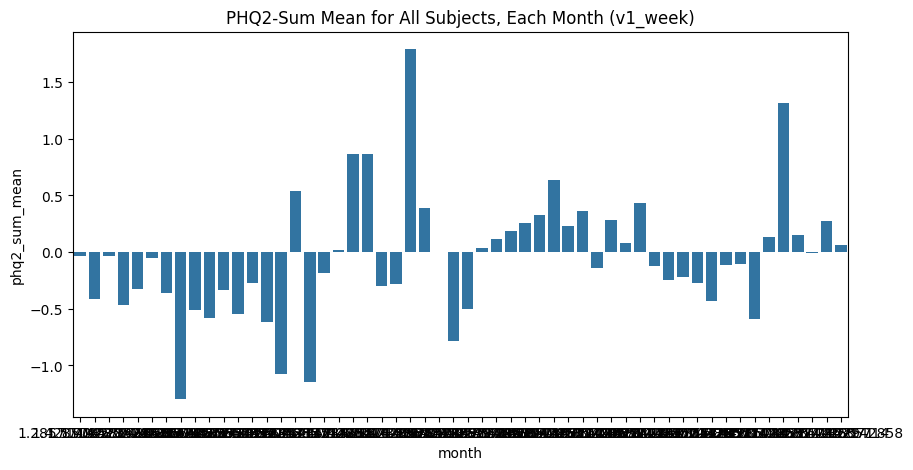

################# v2_week ##################


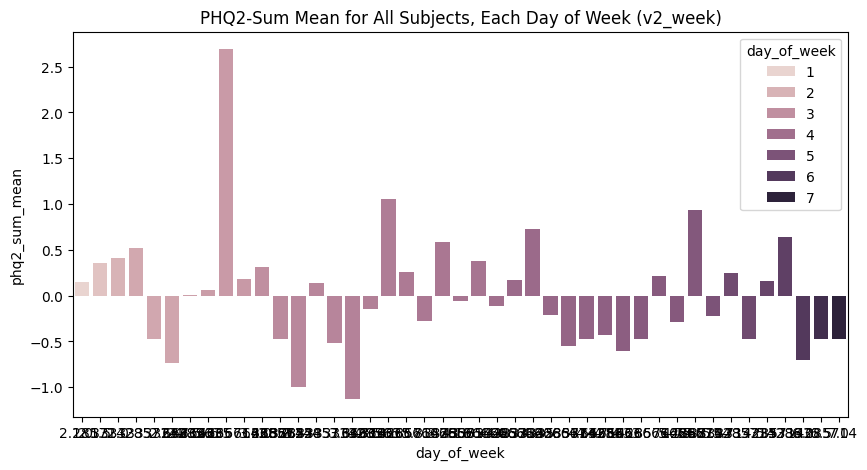

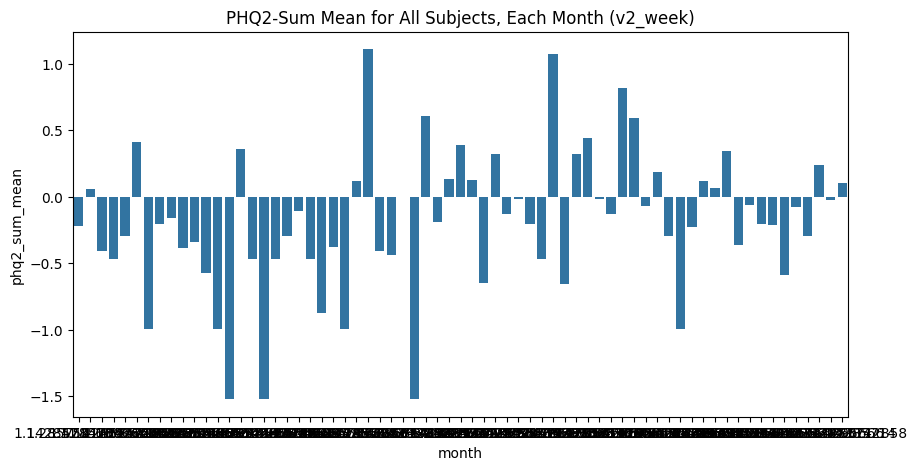

In [ ]:
# Investigate for Seasonality
for name in df_names:
	print(f'################# {name} ##################')
	train = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval.csv'))
	days_of_week = []
	means=[]
	for i, day_df in train.groupby('day_of_week'):
		days_of_week.append(i)
		means.append(day_df['phq2_sum'].mean())
	day_means = pd.DataFrame([days_of_week, means], index=['day_of_week', 'phq2_sum_mean'])
	day_means = day_means.T
	# display(day_means)
	plt.figure(figsize=(10, 5))
	sns.barplot(data=day_means,x='day_of_week', y='phq2_sum_mean', hue='day_of_week')
	plt.title(f'PHQ2-Sum Mean for All Subjects, Each Day of Week ({name})')
	plt.show()

	months = []
	means=[]
	for i, month_df in train.groupby('month'):
		months.append(i)
		means.append(month_df['phq2_sum'].mean())
	month_means = pd.DataFrame([months, means], index=['month', 'phq2_sum_mean'])
	month_means=month_means.T
	# display(month_means)
	plt.figure(figsize=(10, 5))
	sns.barplot(data=month_means,x='month', y='phq2_sum_mean')
	plt.title(f'PHQ2-Sum Mean for All Subjects, Each Month ({name})')
	plt.show()

	
	



In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

import plotly.express as px

for name in ['v1_week', 'v2_week']:
	print(f'################# {name} ##################')
	train = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_imputed.csv'))
	change_in_phq9_cat = []
	for i, sub_df in train.groupby('num_id'):
			sub_df=sub_df.dropna(subset='phq9_cat')
			sub_df = sub_df.sort_values('day')
			if sub_df.shape[0]>0:
				og_cat = sub_df.iloc[0]['phq9_cat']
				end_cat = sub_df.iloc[sub_df.shape[0]-1]['phq9_cat']
				try: 
					cat_diff = end_cat-og_cat
					weeks = sub_df['week'].max()
					if weeks > 4:
						if cat_diff < 0:
							 diff_cat = -1
						elif cat_diff > 0:
							 diff_cat = 1
						else: 
							 diff_cat = 0
						change_in_phq9_cat.append([i, cat_diff, weeks, diff_cat])
						 
				except Exception as e:
					print(i, e)
					continue
			
	change_df = pd.DataFrame(change_in_phq9_cat, columns=['sub', 'change', 'weeks', 'change_category'])
	#display(change_df)

	fig = px.histogram(change_df, x='change', color='weeks', barmode='stack', title=f'Change in PHQ9_Sum Category Change from Onboarding to Final Week ({name})')
	fig.show()

	fig2 = px.histogram(change_df, x='change_category', color='weeks', barmode='stack', title=f'change_category in PHQ9_Sum Category Change from Onboarding to Final Week ({name})')
	fig2.show()


Run on: Mon 13 Apr 2026, 08:56AM
################# v1_week ##################


################# v2_week ##################
